# 04 — E-GEO Benchmark-Style Final Tables and Figures with Provider-Style Metrics

This reporting notebook reads the canonical outputs from notebooks 01, 02, and 03 and writes final manuscript tables and figures. This dash-fill version also reads notebook 02 official-test baseline outputs so that Random, TF-IDF cosine, and E5-base rows in Supplementary Table S1 can be populated when the corresponding metrics were computed.

**Replace policy:** final CSV/TeX/figure outputs use fixed filenames and are overwritten on rerun.


In [1]:
# %pip install -q -U pandas numpy matplotlib

In [2]:
# !pip install -U --force-reinstall matplotlib

## 1. Setup and helper functions

In [3]:
from pathlib import Path
import sys, os, math, warnings
from textwrap import fill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/Finance Research/E-GEO-ML")
if not PROJECT_ROOT.exists():
    CWD = Path.cwd().resolve()
    if (CWD / "data").exists() and (CWD / "raw_data").exists():
        PROJECT_ROOT = CWD
    elif (CWD.parent / "data").exists() and (CWD.parent / "raw_data").exists():
        PROJECT_ROOT = CWD.parent
    else:
        PROJECT_ROOT = CWD.parent if CWD.name.lower() == "code" else CWD

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
MAIN_FIG_DIR = FIGURES_DIR / "main_benchmark_final"
SUPP_FIG_DIR = FIGURES_DIR / "supplementary_benchmark_final"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLE_DIR = DATA_DIR / "manuscript_tables_benchmark_final"
for d in [DATA_DIR, MAIN_FIG_DIR, SUPP_FIG_DIR, RESULTS_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MAIN_FIG_DIR:", MAIN_FIG_DIR)
print("SUPP_FIG_DIR:", SUPP_FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)

FIG_WIDTH_170MM = 170 / 25.4
FIG_WIDTH_85MM = 85 / 25.4
DPI = 600

COLORS = {
    "navy": "#355C7D", "blue": "#5B7FA3", "lightblue": "#A8BED6",
    "orange": "#C97B63", "green": "#6C8A6B", "gray": "#9A9A9A",
    "darkgray": "#555555", "lightgray": "#D9D9D9", "black": "#222222"
}
HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "paper_blues", ["#F7F7F7", "#D5E0EC", "#8EADC8", "#355C7D"]
)

plt.rcParams.update({
    "figure.dpi": DPI, "savefig.dpi": DPI,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7.2, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.8, "ytick.labelsize": 6.8, "legend.fontsize": 6.6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

MODEL_ORDER = ["gpt5", "gpt41", "gemini", "claude", "deepseek", "llama"]
MODEL_NAME_MAP = {"gpt5":"GPT-5", "gpt41":"GPT-4.1", "gemini":"Gemini", "claude":"Claude", "deepseek":"DeepSeek", "llama":"Llama"}
METHOD_NAME_MAP = {
    "textnum_tfidf_logreg":"TF-IDF + numeric LR", "text_tfidf_logreg":"TF-IDF LR",
    "numeric_logreg":"Numeric LR", "numeric_random_forest":"Numeric RF",
    "numeric_extra_trees":"Numeric ExtraTrees", "numeric_xgboost":"Numeric XGBoost",
    "numeric_lightgbm":"Numeric LightGBM", "numeric_hist_gradient_boosting":"Numeric HGB",
    "textnum_tfidf_sgd_logloss":"TF-IDF + numeric SGD", "textsvd_num_logreg":"TF-IDF SVD + numeric LR",
    "tfidf_compact_cosine":"TF-IDF cosine", "embed_minilm_l6_cosine":"MiniLM",
    "embed_multiqa_minilm_cosine":"MultiQA", "embed_e5_base_cosine":"E5-base",
    "rerank_msmarco_minilm_l6":"MS MARCO L6", "rerank_msmarco_minilm_l12":"MS MARCO L12",
    "rerank_bge_base":"BGE reranker", "hybrid_all_available":"Hybrid", "hybrid_neural_retrieval_score":"Hybrid",
}
FEATURE_NAME_MAP = {
    "tfidf_query_product_cosine":"TF-IDF query-product similarity",
    "query_product_overlap":"Query-product overlap", "query_title_overlap":"Query-title overlap",
    "query_features_overlap":"Query-feature overlap", "evidence_keyword_count":"Evidence keyword count",
    "numeric_count_product_text":"Numeric/spec count", "product_text_len_words":"Product text length",
    "log_rating_number":"Log rating count", "average_rating":"Average rating",
    "feature_count":"Feature count", "details_len_words":"Details text length", "query_len_words":"Query text length",
}
figure_manifest = []

def read_csv_optional(path, **kwargs):
    path = Path(path)
    if path.exists():
        print(f"Loaded: {path.name}")
        return pd.read_csv(path, **kwargs)
    print(f"Missing: {path.name}")
    return None

def model_label(x): return MODEL_NAME_MAP.get(str(x), str(x))
def method_label(x):
    x = str(x).replace("official_test_", "")
    return METHOD_NAME_MAP.get(x, x.replace("_", " "))
def feature_label(x, width=20):
    return fill(FEATURE_NAME_MAP.get(str(x), str(x).replace("_", " ")), width=width)

def clean_axes(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis in {"x", "y"}:
        ax.grid(axis=grid_axis, color=COLORS["lightgray"], linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)

def reorder_models(df, col):
    order = {m: i for i, m in enumerate(MODEL_ORDER)}
    return df.assign(_order=df[col].map(order).fillna(999)).sort_values("_order").drop(columns="_order")

def add_aligned_panel_labels(fig, axes, labels, dx=0.012, dy=0.008):
    fig.canvas.draw()
    pos = [ax.get_position() for ax in axes]
    top_y = max(p.y1 for p in pos) + dy
    for ax, lab, p in zip(axes, labels, pos):
        fig.text(p.x0 - dx, top_y, f"{lab})", fontsize=8.8, fontweight="bold", ha="left", va="bottom", color=COLORS["black"])

def save_figure(fig, filename, category, caption, source_files):
    out_dir = MAIN_FIG_DIR if category == "main" else SUPP_FIG_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"{filename}.png"
    pdf_path = out_dir / f"{filename}.pdf"
    svg_path = out_dir / f"{filename}.svg"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    figure_manifest.append({"figure_id":filename, "category":category, "png_path":str(png_path), "pdf_path":str(pdf_path), "svg_path":str(svg_path), "caption":caption, "source_files":source_files})
    print("Saved:", png_path)
    print("Saved:", pdf_path)
    print("Saved:", svg_path)

def draw_heatmap(ax, data, row_labels, col_labels, cmap=HEATMAP_CMAP, vmin=None, vmax=None, fmt=".3f"):
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(col_labels))); ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right"); ax.set_yticklabels(row_labels)
    midpoint = None if (vmin is None or vmax is None) else vmin + 0.55 * (vmax - vmin)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=5.5,
                        color=("white" if midpoint is not None and val > midpoint else COLORS["black"]))
    return im

def round_table_for_csv(df, decimals=3):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(decimals)
    return out

def best_second_format_latex(df, metric_cols):
    out = df.copy()
    for col in metric_cols:
        if col not in out.columns: continue
        vals = pd.to_numeric(out[col], errors="coerce")
        finite = vals.dropna().sort_values(ascending=False)
        if len(finite) == 0: continue
        best = finite.iloc[0]; second = finite.iloc[1] if len(finite) > 1 else None
        formatted = []
        for v in vals:
            if pd.isna(v): formatted.append("")
            elif np.isclose(v, best): formatted.append(f"\\textbf{{{v:.3f}}}")
            elif second is not None and np.isclose(v, second): formatted.append(f"\\underline{{{v:.3f}}}")
            else: formatted.append(f"{v:.3f}")
        out[col] = formatted
    return out

def save_latex_table(df, path, caption=None, label=None):
    tex = df.to_latex(index=False, escape=False)
    lines = ["\\begin{table}[htbp]", "\\centering", "\\scriptsize", tex]
    if caption: lines.append(f"\\caption{{{caption}}}")
    if label: lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    Path(path).write_text("\n".join(lines), encoding="utf-8")
    print("Saved:", path)

def official_value(metric_df, query_df, method_name, metric):
    """Return official-test metrics for trained ML models.

    Supports row-level metrics such as AUPRC and query-level metrics such as
    NDCG@3, SOV captured@3, top-1 hit@3, and mean true position@3.
    """
    names = [f"official_test_{method_name}", method_name]
    row_metric_map = {
        "AUPRC": "AUPRC", "AUROC": "AUROC", "F1": "F1",
        "Accuracy": "Accuracy", "Precision": "Precision", "Recall": "Recall",
    }
    query_metric_map = {
        "NDCG@3": "ndcg@3", "ndcg@3": "ndcg@3",
        "SOV captured@3": "sov_captured@3", "sov_captured@3": "sov_captured@3",
        "Top-1 hit@3": "top1_hit@3", "top1_hit@3": "top1_hit@3",
        "Mean true position@3": "mean_true_position@3", "mean_true_position@3": "mean_true_position@3",
        "Top3 SOV captured@3": "top3_sov_captured@3", "top3_sov_captured@3": "top3_sov_captured@3",
    }
    if metric in row_metric_map:
        if metric_df is None:
            return np.nan
        row = next((n for n in names if n in metric_df.index), None)
        col = row_metric_map[metric]
        if row is None or col not in metric_df.columns:
            return np.nan
        vals = pd.to_numeric(pd.Series([metric_df.loc[row, col]]), errors="coerce").dropna()
        return float(vals.iloc[0]) if len(vals) else np.nan
    if metric in query_metric_map:
        if query_df is None:
            return np.nan
        row = next((n for n in names if n in query_df.index), None)
        col = query_metric_map[metric]
        if row is None or col not in query_df.columns:
            return np.nan
        vals = pd.to_numeric(pd.Series([query_df.loc[row, col]]), errors="coerce").dropna()
        return float(vals.iloc[0]) if len(vals) else np.nan
    return np.nan


# ------------------------------------------------------------
# FIXED helper overrides
# ------------------------------------------------------------
SEARCH_DIRS = [DATA_DIR, PROJECT_ROOT, TABLE_DIR, Path.cwd().resolve()]

def resolve_existing_path(path):
    p = Path(path)
    candidates = [p]
    # Even when an absolute DATA_DIR path is missing, also search by basename.
    for d in SEARCH_DIRS:
        candidates.append(d / p.name)
        if not p.is_absolute() and len(p.parts) > 1:
            candidates.append(d / p)
    seen = set()
    for c in candidates:
        c = c.resolve()
        if c in seen:
            continue
        seen.add(c)
        if c.exists():
            return c
    return Path(path)

def read_csv_optional(path, **kwargs):
    p = resolve_existing_path(path)
    if p.exists():
        print(f"Loaded: {p}")
        return pd.read_csv(p, **kwargs)
    print(f"Missing: {path}")
    return None

def round_table_for_csv(df, decimals=3, missing="--"):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(decimals)
    if missing is not None:
        out = out.replace({np.nan: missing})
    return out

def best_second_format_latex(df, metric_cols, missing="--"):
    out = df.copy()
    for col in metric_cols:
        if col not in out.columns:
            continue
        vals = pd.to_numeric(out[col], errors="coerce")
        finite = vals.dropna().sort_values(ascending=False)
        if len(finite) == 0:
            out[col] = [missing] * len(out)
            continue
        best = finite.iloc[0]
        second = finite.iloc[1] if len(finite) > 1 else None
        formatted = []
        for v in vals:
            if pd.isna(v):
                formatted.append(missing)
            elif np.isclose(v, best):
                formatted.append(f"\\textbf{{{v:.3f}}}")
            elif second is not None and np.isclose(v, second):
                formatted.append(f"\\underline{{{v:.3f}}}")
            else:
                formatted.append(f"{v:.3f}")
        out[col] = formatted
    return out

def first_existing_column(df, candidates):
    if df is None:
        return None
    lower = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None



# ============================================================
# Replace-save policy
# ============================================================
# All generated CSV/TEX/manifest outputs are written to canonical filenames.
# Existing files with the same names are removed first, then replaced.
# This avoids accumulating duplicate output files across repeated runs.
# ============================================================

if not hasattr(pd.DataFrame, "_egeo_original_to_csv"):
    pd.DataFrame._egeo_original_to_csv = pd.DataFrame.to_csv


def _to_csv_replace(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike, Path)):
        p = Path(path_or_buf)
        p.parent.mkdir(parents=True, exist_ok=True)
        if p.exists():
            p.unlink()
    return pd.DataFrame._egeo_original_to_csv(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_replace
print("Replace-save policy: enabled. Existing table CSV outputs with the same names will be replaced.")


# ============================================================
# Provider-style metric aliases
# ============================================================
# These are industry-aligned metrics from the AI visibility provider audit
# translated into E-GEO ranking proxies.
# ============================================================

QUERY_METRIC_ALIASES = {
    "NDCG@3": "ndcg@3",
    "ndcg@3": "ndcg@3",
    "SOV captured@3": "sov_captured@3",
    "sov_captured@3": "sov_captured@3",
    "Top3 SOV captured@3": "top3_sov_captured@3",
    "top3_sov_captured@3": "top3_sov_captured@3",
    "Top-1 hit@3": "top1_hit@3",
    "top1_hit@3": "top1_hit@3",
    "Mean true position@3": "mean_true_position@3",
    "mean_true_position@3": "mean_true_position@3",
}

ROW_METRIC_NAMES = {"AUPRC", "AUROC", "F1", "Accuracy", "Precision", "Recall"}


def query_metric_value(query_df, method_name, metric):
    """Return one query-level metric for a method from a method-indexed table."""
    if query_df is None:
        return np.nan
    metric_col = QUERY_METRIC_ALIASES.get(metric, metric)
    names = [f"official_test_{method_name}", method_name]
    row = next((n for n in names if n in query_df.index), None)
    if row is None or metric_col not in query_df.columns:
        return np.nan
    vals = pd.to_numeric(pd.Series([query_df.loc[row, metric_col]]), errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan


def official_value(metric_df, query_df, method_name, metric):
    """Return row- or query-level metric for validation/test tables."""
    if metric in ROW_METRIC_NAMES:
        if metric_df is None:
            return np.nan
        names = [f"official_test_{method_name}", method_name]
        row = next((n for n in names if n in metric_df.index), None)
        if row is None or metric not in metric_df.columns:
            return np.nan
        vals = pd.to_numeric(pd.Series([metric_df.loc[row, metric]]), errors="coerce").dropna()
        return float(vals.iloc[0]) if len(vals) else np.nan

    return query_metric_value(query_df, method_name, metric)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Finance Research/E-GEO-ML
DATA_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/data
MAIN_FIG_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final
SUPP_FIG_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final
TABLE_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final
Replace-save policy: enabled. Existing table CSV outputs with the same names will be replaced.


## 3. Load existing CSV outputs

In [4]:
valid_split = read_csv_optional(DATA_DIR / "egeo_gpt5_internal_valid_split.csv")
visibility_gpt5 = read_csv_optional(DATA_DIR / "egeo_train_val_visibility_gpt5.csv")

# Standard intermediate outputs from notebook 01
gpt5_metrics_valid = read_csv_optional(DATA_DIR / "egeo_gpt5_classification_metrics_valid.csv", index_col=0)
gpt5_query_metrics_valid = read_csv_optional(DATA_DIR / "egeo_gpt5_query_level_metrics_valid.csv", index_col=0)
gpt5_metrics_test = read_csv_optional(DATA_DIR / "egeo_gpt5_classification_metrics_official_test.csv", index_col=0)
gpt5_query_metrics_test = read_csv_optional(DATA_DIR / "egeo_gpt5_query_level_metrics_official_test.csv", index_col=0)

cross_model_metrics = read_csv_optional(DATA_DIR / "egeo_cross_model_robustness_metrics.csv")
neural_query_all = read_csv_optional(DATA_DIR / "egeo_pretrained_neural_query_metrics_all_label_models.csv")
neural_row_all = read_csv_optional(DATA_DIR / "egeo_pretrained_neural_row_metrics_all_label_models.csv")

feature_importance_all = read_csv_optional(DATA_DIR / "feature_importance_gpt5_all_tree_models.csv")
rank_group_profiles = read_csv_optional(DATA_DIR / "figure_rank_group_standardized_feature_profiles.csv", index_col=0)

# New notebook 02 output used to complete non-trained baseline rows in S1.
nontrained_baseline_summary = read_csv_optional(DATA_DIR / "egeo_02_nontrained_baseline_summary.csv")
if nontrained_baseline_summary is None:
    nontrained_baseline_summary = read_csv_optional(DATA_DIR / "egeo_nontrained_baseline_metrics.csv")

# Final manuscript tables can be used as fallback if the intermediate 01/02 files were not uploaded.
existing_s1 = read_csv_optional(TABLE_DIR / "supp_tableS1_benchmark_summary.csv")
existing_s2 = read_csv_optional(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv")
existing_s3 = read_csv_optional(TABLE_DIR / "supp_tableS3_feature_diagnostics.csv")
if existing_s1 is None:
    existing_s1 = read_csv_optional(DATA_DIR / "supp_tableS1_benchmark_summary.csv")
if existing_s2 is None:
    existing_s2 = read_csv_optional(DATA_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv")
if existing_s3 is None:
    existing_s3 = read_csv_optional(DATA_DIR / "supp_tableS3_feature_diagnostics.csv")

# Reconstruct minimal GPT-5 metric tables from S2 if the original 01 metric CSVs are missing.
def reconstruct_metric_tables_from_s2(s2):
    if s2 is None or len(s2) == 0:
        return None, None, None, None
    key_col = first_existing_column(s2, ["Raw model key", "raw_model_key", "model"])
    if key_col is None:
        return None, None, None, None
    keys = s2[key_col].astype(str).tolist()
    mv = pd.DataFrame(index=keys)
    qv = pd.DataFrame(index=keys)
    mt = pd.DataFrame(index=keys)
    qt = pd.DataFrame(index=keys)
    colmap = {
        "AUROC": first_existing_column(s2, ["Valid AUROC ↑", "Valid AUROC", "AUROC"]),
        "AUPRC": first_existing_column(s2, ["Valid AUPRC ↑", "Valid AUPRC", "AUPRC"]),
        "F1": first_existing_column(s2, ["Valid F1 ↑", "Valid F1", "F1"]),
        "valid_ndcg": first_existing_column(s2, ["Valid NDCG@3 ↑", "Valid NDCG@3", "ndcg@3"]),
        "valid_sov": first_existing_column(s2, ["Valid SOV captured@3 ↑", "Valid SOV captured@3", "sov_captured@3"]),
        "valid_top1": first_existing_column(s2, ["Valid top-1 hit@3 ↑", "Valid top-1 hit@3", "top1_hit@3"]),
        "valid_meanpos": first_existing_column(s2, ["Valid mean true position@3 ↓", "Valid mean true position@3", "mean_true_position@3"]),
        "test_auprc": first_existing_column(s2, ["Test AUPRC ↑", "Test AUPRC"]),
        "test_ndcg": first_existing_column(s2, ["Test NDCG@3 ↑", "Test NDCG@3"]),
        "test_sov": first_existing_column(s2, ["Test SOV captured@3 ↑", "Test SOV captured@3"]),
        "test_top1": first_existing_column(s2, ["Test top-1 hit@3 ↑", "Test top-1 hit@3"]),
        "test_meanpos": first_existing_column(s2, ["Test mean true position@3 ↓", "Test mean true position@3"]),
    }
    for metric in ["AUROC", "AUPRC", "F1"]:
        c = colmap.get(metric)
        if c is not None:
            mv[metric] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("valid_ndcg")
    if c is not None:
        qv["ndcg@3"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    for key, out_col in [("valid_sov", "sov_captured@3"), ("valid_top1", "top1_hit@3"), ("valid_meanpos", "mean_true_position@3")]:
        c = colmap.get(key)
        if c is not None:
            qv[out_col] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("test_auprc")
    if c is not None:
        mt["AUPRC"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("test_ndcg")
    if c is not None:
        qt["ndcg@3"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    for key, out_col in [("test_sov", "sov_captured@3"), ("test_top1", "top1_hit@3"), ("test_meanpos", "mean_true_position@3")]:
        c = colmap.get(key)
        if c is not None:
            qt[out_col] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    return mv, qv, mt, qt

if (gpt5_metrics_valid is None or gpt5_query_metrics_valid is None) and existing_s2 is not None:
    mv, qv, mt, qt = reconstruct_metric_tables_from_s2(existing_s2)
    if gpt5_metrics_valid is None and mv is not None:
        gpt5_metrics_valid = mv
        print("Reconstructed gpt5_metrics_valid from S2.")
    if gpt5_query_metrics_valid is None and qv is not None:
        gpt5_query_metrics_valid = qv
        print("Reconstructed gpt5_query_metrics_valid from S2.")
    if gpt5_metrics_test is None and mt is not None:
        gpt5_metrics_test = mt
        print("Reconstructed gpt5_metrics_test from S2.")
    if gpt5_query_metrics_test is None and qt is not None:
        gpt5_query_metrics_test = qt
        print("Reconstructed gpt5_query_metrics_test from S2.")

print("\nLoaded outputs:")
for name, obj in {
    "valid_split": valid_split,
    "gpt5_metrics_valid": gpt5_metrics_valid,
    "gpt5_query_metrics_valid": gpt5_query_metrics_valid,
    "gpt5_metrics_test": gpt5_metrics_test,
    "gpt5_query_metrics_test": gpt5_query_metrics_test,
    "cross_model_metrics": cross_model_metrics,
    "neural_query_all": neural_query_all,
    "nontrained_baseline_summary": nontrained_baseline_summary,
    "feature_importance_all": feature_importance_all,
    "existing_s2": existing_s2,
}.items():
    if obj is not None:
        print(f"{name}: {obj.shape}")


Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_internal_valid_split.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_train_val_visibility_gpt5.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_classification_metrics_valid.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_query_level_metrics_valid.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_classification_metrics_official_test.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_query_level_metrics_official_test.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_cross_model_robustness_metrics.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_pretrained_neural_query_metrics_all_label_models.csv
Loaded: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_pretrained_neural_row_metrics_all_label_models.csv
Loaded: /content/drive/MyDrive/Finan

## 4. Compute headline values and helper tables

In [5]:
assert gpt5_metrics_valid is not None and gpt5_query_metrics_valid is not None, "Missing GPT-5 metric CSVs. Run notebook 01 first."

# Random baseline
random_ndcg_gpt5, random_auprc_gpt5 = np.nan, np.nan
if valid_split is not None and "top3" in valid_split.columns:
    random_auprc_gpt5 = float(valid_split["top3"].mean())
    rng = np.random.default_rng(42)
    tmp = valid_split.copy()
    tmp["random_score"] = rng.random(len(tmp))
    def ndcg_at_k(group, k=3):
        g = group.sort_values("random_score", ascending=False).head(k)
        rel = g["top3"].to_numpy()
        dcg = sum(rel[i] / math.log2(i + 2) for i in range(len(rel)))
        ideal = np.sort(group["top3"].to_numpy())[::-1][:k]
        idcg = sum(ideal[i] / math.log2(i + 2) for i in range(len(ideal)))
        return dcg / idcg if idcg > 0 else np.nan
    random_ndcg_gpt5 = float(tmp.groupby("query_id").apply(ndcg_at_k).mean())

# Best trained ML on GPT-5 validation NDCG@3
best_trained_method = gpt5_query_metrics_valid["ndcg@3"].idxmax()

# Lexical baseline: prefer TF-IDF cosine from neural baseline file; fallback to trained TF-IDF LR
lexical_method, lexical_ndcg, lexical_auprc = None, np.nan, np.nan
if neural_query_all is not None and neural_row_all is not None:
    q = neural_query_all[(neural_query_all["label_model"] == "gpt5") & (neural_query_all["score_model"] == "tfidf_compact_cosine")]
    r = neural_row_all[(neural_row_all["label_model"] == "gpt5") & (neural_row_all["score_model"] == "tfidf_compact_cosine")]
    if len(q) > 0:
        lexical_method = "tfidf_compact_cosine"
        lexical_ndcg = float(q.iloc[0]["ndcg@3"])
        lexical_auprc = float(r.iloc[0]["AUPRC"]) if len(r) > 0 and "AUPRC" in r.columns else np.nan
if lexical_method is None and "text_tfidf_logreg" in gpt5_query_metrics_valid.index:
    lexical_method = "text_tfidf_logreg"
    lexical_ndcg = float(gpt5_query_metrics_valid.loc[lexical_method, "ndcg@3"])
    lexical_auprc = float(gpt5_metrics_valid.loc[lexical_method, "AUPRC"])

# Best pretrained neural excluding lexical TF-IDF cosine
best_neural_method, best_neural_ndcg, best_neural_auprc = None, np.nan, np.nan
if neural_query_all is not None and neural_row_all is not None:
    q = neural_query_all[(neural_query_all["label_model"] == "gpt5") & (neural_query_all["score_model"] != "tfidf_compact_cosine")].copy()
    if len(q) > 0:
        q = q.sort_values("ndcg@3", ascending=False)
        best_neural_method = q.iloc[0]["score_model"]
        best_neural_ndcg = float(q.iloc[0]["ndcg@3"])
        r = neural_row_all[(neural_row_all["label_model"] == "gpt5") & (neural_row_all["score_model"] == best_neural_method)]
        best_neural_auprc = float(r.iloc[0]["AUPRC"]) if len(r) > 0 and "AUPRC" in r.columns else np.nan


# For Supplementary Table S1, use E5-base as the representative pretrained-neural row when available.
# This matches the manuscript table and avoids changing the representative method if a different neural scorer happens to win.
if neural_query_all is not None:
    e5_q = neural_query_all[
        (neural_query_all["label_model"].astype(str) == "gpt5") &
        (neural_query_all["score_model"].astype(str) == "embed_e5_base_cosine")
    ]
    if len(e5_q) > 0:
        best_neural_method = "embed_e5_base_cosine"
        best_neural_ndcg = float(pd.to_numeric(e5_q.iloc[0].get("ndcg@3", np.nan), errors="coerce"))
        if neural_row_all is not None:
            e5_r = neural_row_all[
                (neural_row_all["label_model"].astype(str) == "gpt5") &
                (neural_row_all["score_model"].astype(str) == "embed_e5_base_cosine")
            ]
            if len(e5_r) > 0 and "AUPRC" in e5_r.columns:
                best_neural_auprc = float(pd.to_numeric(e5_r.iloc[0].get("AUPRC", np.nan), errors="coerce"))
        print("Representative pretrained-neural method for S1:", best_neural_method)

# Cross-label best trained vs best pretrained
best_combined_by_label = None
if cross_model_metrics is not None and neural_query_all is not None:
    best_trained_by_label = (
        cross_model_metrics.sort_values(["label_model", "ndcg@3"], ascending=[True, False])
        .groupby("label_model", as_index=False).first()[["label_model", "baseline_model", "ndcg@3"]]
        .rename(columns={"baseline_model": "best_trained_method", "ndcg@3": "best_trained_ndcg"})
    )
    neural_tmp = neural_query_all[neural_query_all["score_model"] != "tfidf_compact_cosine"].copy()
    best_neural_by_label = (
        neural_tmp.sort_values(["label_model", "ndcg@3"], ascending=[True, False])
        .groupby("label_model", as_index=False).first()[["label_model", "score_model", "ndcg@3"]]
        .rename(columns={"score_model": "best_pretrained_method", "ndcg@3": "best_pretrained_ndcg"})
    )
    best_combined_by_label = best_trained_by_label.merge(best_neural_by_label, on="label_model", how="inner")
    best_combined_by_label["gain_trained_minus_pretrained"] = best_combined_by_label["best_trained_ndcg"] - best_combined_by_label["best_pretrained_ndcg"]
    best_combined_by_label = reorder_models(best_combined_by_label, "label_model")

# Feature importance summary
feature_importance_summary = None
if feature_importance_all is not None and {"feature", "importance"}.issubset(feature_importance_all.columns):
    imp = feature_importance_all.copy()
    if "model" in imp.columns:
        imp["importance_norm"] = imp.groupby("model")["importance"].transform(lambda x: 100 * x / x.sum() if x.sum() != 0 else x)
        feature_importance_summary = imp.groupby("feature")["importance_norm"].mean().sort_values(ascending=False).reset_index()
    else:
        imp["importance_norm"] = 100 * imp["importance"] / imp["importance"].sum()
        feature_importance_summary = imp.sort_values("importance_norm", ascending=False)[["feature", "importance_norm"]]

# Rank group profile fallback
if rank_group_profiles is None:
    src = valid_split if valid_split is not None and "rank" in valid_split.columns else visibility_gpt5
    if src is not None and "rank" in src.columns:
        candidate = ["tfidf_query_product_cosine", "query_product_overlap", "query_title_overlap", "query_features_overlap", "evidence_keyword_count", "numeric_count_product_text", "product_text_len_words", "log_rating_number", "average_rating", "feature_count", "details_len_words", "query_len_words"]
        cols = [c for c in candidate if c in src.columns]
        z = src[cols].apply(pd.to_numeric, errors="coerce")
        z = (z - z.mean()) / z.std(ddof=0)
        z["rank_group"] = pd.cut(src["rank"], bins=[0,3,7,10], labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"], include_lowest=True)
        rank_group_profiles = z.groupby("rank_group")[cols].mean()

print("Best trained method:", best_trained_method, method_label(best_trained_method))
print("Lexical method:", lexical_method, method_label(lexical_method) if lexical_method else None)
print("Best pretrained neural:", best_neural_method, method_label(best_neural_method) if best_neural_method else None)
print("Random NDCG@3:", random_ndcg_gpt5)
if best_combined_by_label is not None:
    display(best_combined_by_label)


Representative pretrained-neural method for S1: embed_e5_base_cosine
Best trained method: textnum_tfidf_logreg TF-IDF + numeric LR
Lexical method: tfidf_compact_cosine TF-IDF cosine
Best pretrained neural: embed_e5_base_cosine E5-base
Random NDCG@3: 0.32569011633320005


,label_model,best_trained_method,best_trained_ndcg,best_pretrained_method,best_pretrained_ndcg,gain_trained_minus_pretrained
4,gpt5,textnum_tfidf_logreg,0.445588,embed_e5_base_cosine,0.352369,0.093219
3,gpt41,textnum_tfidf_logreg,0.431145,hybrid_all_available,0.371167,0.059979
2,gemini,textnum_tfidf_logreg,0.456830,hybrid_all_available,0.372364,0.084466
0,claude,textnum_tfidf_logreg,0.459539,hybrid_all_available,0.362231,0.097308
1,deepseek,textnum_tfidf_logreg,0.453677,embed_e5_base_cosine,0.362527,0.091150
5,llama,textnum_tfidf_logreg,0.452192,hybrid_all_available,0.372677,0.079515


# Main Figure 1 — Compact benchmark result

,family,representative_method,NDCG@3,AUPRC
0,Random,Random ranking,0.325690,0.300000
1,Lexical,TF-IDF cosine,0.302274,0.299724
2,Pretrained\nneural,E5-base,0.352369,0.319822
3,Trained\nML,TF-IDF + numeric LR,0.445588,0.405063


,split,AUPRC,NDCG@3
0,Validation,0.405063,0.445588
1,Official\ntest,0.399809,0.442149


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.svg


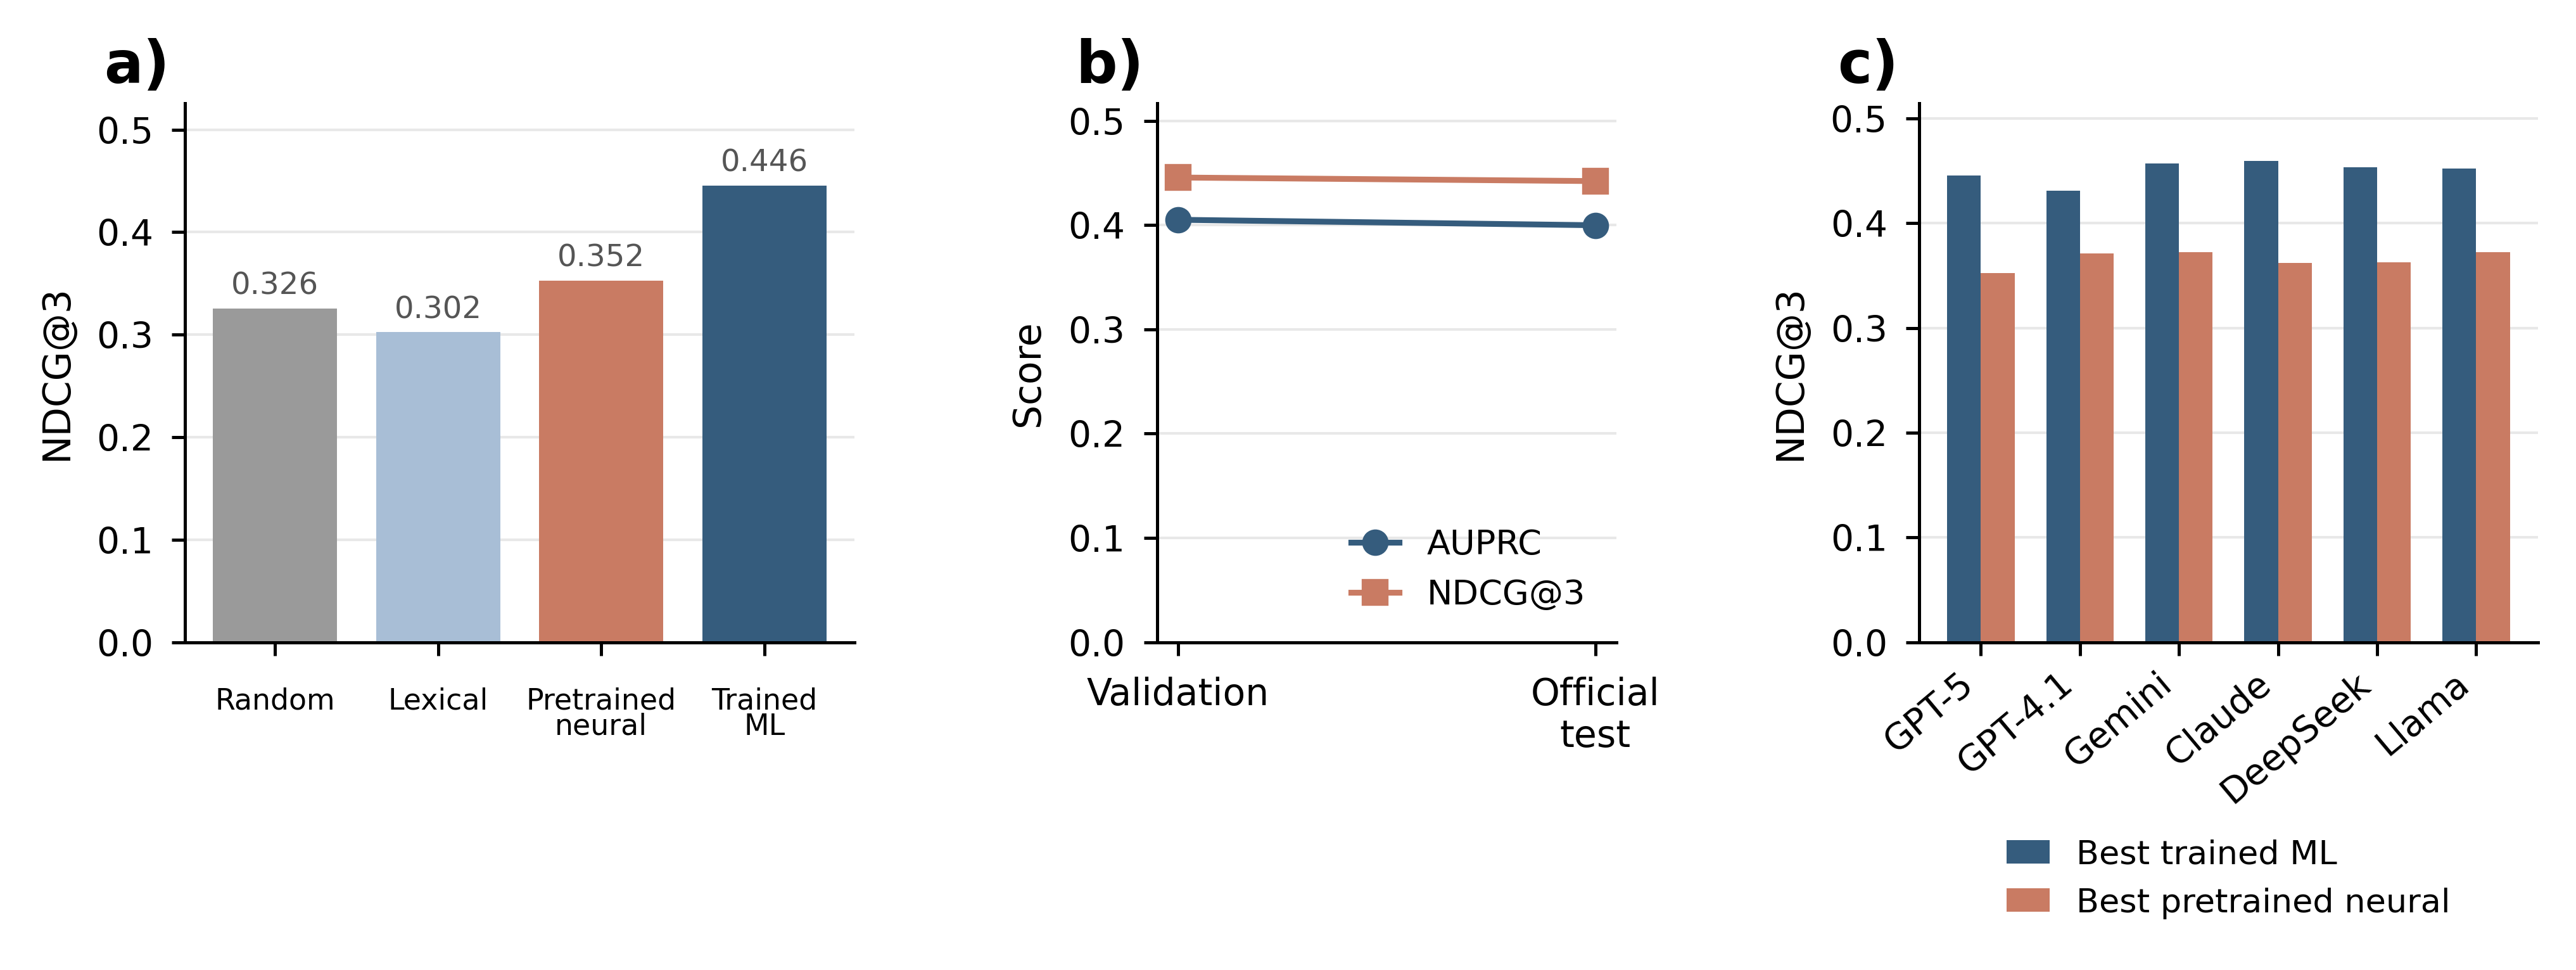

In [6]:
# ------------------------------------------------------------
# Summary tables for main Figure 1
# ------------------------------------------------------------
baseline_rows = []

if not pd.isna(random_ndcg_gpt5):
    baseline_rows.append({
        "family": "Random",
        "representative_method": "Random ranking",
        "NDCG@3": random_ndcg_gpt5,
        "AUPRC": random_auprc_gpt5
    })

if lexical_method is not None:
    baseline_rows.append({
        "family": "Lexical",
        "representative_method": method_label(lexical_method),
        "NDCG@3": lexical_ndcg,
        "AUPRC": lexical_auprc
    })

if best_neural_method is not None:
    baseline_rows.append({
        "family": "Pretrained\nneural",
        "representative_method": method_label(best_neural_method),
        "NDCG@3": best_neural_ndcg,
        "AUPRC": best_neural_auprc
    })

baseline_rows.append({
    "family": "Trained\nML",
    "representative_method": method_label(best_trained_method),
    "NDCG@3": float(gpt5_query_metrics_valid.loc[best_trained_method, "ndcg@3"]),
    "AUPRC": float(gpt5_metrics_valid.loc[best_trained_method, "AUPRC"])
})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(TABLE_DIR / "main_fig1_baseline_summary.csv", index=False)
display(baseline_df)


split_rows = [{
    "split": "Validation",
    "AUPRC": float(gpt5_metrics_valid.loc[best_trained_method, "AUPRC"]),
    "NDCG@3": float(gpt5_query_metrics_valid.loc[best_trained_method, "ndcg@3"])
}]

q_name = next(
    (
        n for n in [f"official_test_{best_trained_method}", best_trained_method]
        if gpt5_query_metrics_test is not None and n in gpt5_query_metrics_test.index
    ),
    None
)

r_name = next(
    (
        n for n in [f"official_test_{best_trained_method}", best_trained_method]
        if gpt5_metrics_test is not None and n in gpt5_metrics_test.index
    ),
    None
)

if q_name is not None and r_name is not None:
    split_rows.append({
        "split": "Official\ntest",
        "AUPRC": float(gpt5_metrics_test.loc[r_name, "AUPRC"]),
        "NDCG@3": float(gpt5_query_metrics_test.loc[q_name, "ndcg@3"])
    })

split_df = pd.DataFrame(split_rows)
split_df.to_csv(TABLE_DIR / "main_fig1_split_stability.csv", index=False)
display(split_df)


# ------------------------------------------------------------
# Main Figure 1
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(FIG_WIDTH_170MM, 2.78),
    gridspec_kw={"width_ratios": [1.34, 0.92, 1.24]}
)

fig.subplots_adjust(
    left=0.065,
    right=0.99,
    bottom=0.33,
    top=0.84,
    wspace=0.52
)


# ------------------------------------------------------------
# a) baseline comparison
# ------------------------------------------------------------
family_colors = {
    "Random": COLORS["gray"],
    "Lexical": COLORS["lightblue"],
    "Pretrained\nneural": COLORS["orange"],
    "Trained\nML": COLORS["navy"]
}

x = np.arange(len(baseline_df))

axes[0].bar(
    x,
    baseline_df["NDCG@3"],
    color=[family_colors.get(f, COLORS["blue"]) for f in baseline_df["family"]],
    edgecolor="none",
    width=0.76
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["Random", "Lexical", "Pretrained\nneural", "Trained\nML"],
    fontsize=5.5
)
axes[0].tick_params(axis="x", pad=6)
axes[0].margins(x=0.08)
axes[0].set_xlim(-0.55, len(x) - 0.45)

for lbl in axes[0].get_xticklabels():
    lbl.set_ha("center")
    lbl.set_linespacing(0.86)

axes[0].set_ylabel("NDCG@3")
axes[0].set_ylim(0, max(0.52, baseline_df["NDCG@3"].max() * 1.18))
clean_axes(axes[0], grid_axis="y")

for xi, val in zip(x, baseline_df["NDCG@3"]):
    axes[0].text(
        xi,
        val + 0.008,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=5.8,
        color=COLORS["darkgray"]
    )


# ------------------------------------------------------------
# b) split stability
# ------------------------------------------------------------
sx = np.arange(len(split_df))

axes[1].plot(
    sx,
    split_df["AUPRC"],
    marker="o",
    markersize=4,
    linewidth=1.1,
    color=COLORS["navy"],
    label="AUPRC"
)

axes[1].plot(
    sx,
    split_df["NDCG@3"],
    marker="s",
    markersize=4,
    linewidth=1.1,
    color=COLORS["orange"],
    label="NDCG@3"
)

axes[1].set_xticks(sx)
axes[1].set_xticklabels(split_df["split"], fontsize=7.0)
axes[1].tick_params(axis="x", pad=4)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, max(split_df[["AUPRC", "NDCG@3"]].max()) * 1.16)
clean_axes(axes[1], grid_axis="y")

axes[1].legend(
    frameon=False,
    loc="lower right",
    handlelength=1.4,
    fontsize=6.5
)


# ------------------------------------------------------------
# c) cross-model robustness
# ------------------------------------------------------------
if best_combined_by_label is not None:
    bdf = best_combined_by_label.copy()
    bx = np.arange(len(bdf))
    width = 0.34

    axes[2].bar(
        bx - width / 2,
        bdf["best_trained_ndcg"],
        width=width,
        color=COLORS["navy"],
        edgecolor="none",
        label="Best trained ML"
    )

    axes[2].bar(
        bx + width / 2,
        bdf["best_pretrained_ndcg"],
        width=width,
        color=COLORS["orange"],
        edgecolor="none",
        label="Best pretrained neural"
    )

    axes[2].set_xticks(bx)
    axes[2].set_xticklabels(
        [model_label(v) for v in bdf["label_model"]],
        rotation=40,
        ha="right",
        fontsize=6.8
    )
    axes[2].tick_params(axis="x", pad=2)
    axes[2].set_ylabel("NDCG@3")
    axes[2].set_ylim(
        0,
        max(
            0.50,
            bdf[["best_trained_ndcg", "best_pretrained_ndcg"]].max().max() * 1.12
        )
    )
    clean_axes(axes[2], grid_axis="y")

    axes[2].legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.50, -0.34),
        ncol=1,
        handlelength=1.3,
        fontsize=6.3,
        borderaxespad=0.0
    )

else:
    axes[2].axis("off")
    axes[2].text(
        0.5,
        0.5,
        "Cross-model comparison\nnot available",
        ha="center",
        va="center"
    )


# ------------------------------------------------------------
# Panel labels: move slightly more to the left
# ------------------------------------------------------------
for ax, lab in zip(axes, ["a)", "b)", "c)"]):
    pos = ax.get_position()
    fig.text(
        pos.x0 - 0.032,   # more left
        pos.y1 + 0.008,
        lab,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="bottom"
    )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_figure(
    fig,
    "main_fig1_visibility_prediction_single_170mm",
    "main",
    "Figure 1. Predicting LLM shopping visibility from E-GEO query-product traces. a) GPT-5 query-level ranking recovery for random, lexical, pretrained-neural, and trained-ML baselines. b) Validation and official-test stability for the best trained-ML model. c) Cross-model robustness comparing the best trained-ML and best pretrained-neural baselines across LLM-specific ranking labels.",
    "gpt5 validation/test metrics; cross_model_robustness_metrics; pretrained_neural_query_metrics"
)

plt.show()

# Supplementary Table S1 — Benchmark summary table

In [7]:
def metric_from_table(table, method_name, metric_col):
    if table is None or method_name is None:
        return np.nan
    names = [f"official_test_{method_name}", method_name]
    row = next((n for n in names if n in table.index), None)
    if row is None or metric_col not in table.columns:
        return np.nan
    vals = pd.to_numeric(pd.Series([table.loc[row, metric_col]]), errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan


def cross_model_mean_for_trained(method_name, metric_col="ndcg@3"):
    if cross_model_metrics is None:
        return np.nan
    d = cross_model_metrics[cross_model_metrics["baseline_model"].astype(str) == str(method_name)]
    if len(d) == 0 or metric_col not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric_col], errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else np.nan


def cross_model_mean_for_neural(method_name, metric_col="ndcg@3"):
    if neural_query_all is None:
        return np.nan
    d = neural_query_all[neural_query_all["score_model"].astype(str) == str(method_name)]
    if len(d) == 0 or metric_col not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric_col], errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else np.nan


def metric_from_02(method_key, split, metric, label_model="gpt5"):
    """Lookup baseline metrics from notebook 02 summary.

    Handles both validation/valid labels and canonical method_key values.
    """
    if nontrained_baseline_summary is None or len(nontrained_baseline_summary) == 0:
        return np.nan
    d = nontrained_baseline_summary.copy()
    split_aliases = {
        "valid": ["valid", "validation"],
        "validation": ["validation", "valid"],
        "official_test": ["official_test", "test"],
        "test": ["test", "official_test"],
    }
    splits = split_aliases.get(str(split), [str(split)])
    method_aliases = {
        "E5-base": ["embed_e5_base_cosine", "E5-base"],
        "embed_e5_base_cosine": ["embed_e5_base_cosine", "E5-base"],
        "TF-IDF cosine": ["tfidf_compact_cosine", "TF-IDF cosine"],
        "tfidf_compact_cosine": ["tfidf_compact_cosine", "TF-IDF cosine"],
        "Random ranking": ["random_ranking", "Random ranking"],
        "random_ranking": ["random_ranking", "Random ranking"],
    }
    keys = method_aliases.get(str(method_key), [str(method_key)])
    key_cols = [c for c in ["method_key", "representative_method", "method"] if c in d.columns]
    if key_cols:
        mask = False
        for c in key_cols:
            mask = mask | d[c].astype(str).isin(keys)
        d = d[mask]
    d = d[d["split"].astype(str).isin(splits)] if "split" in d.columns else d
    if label_model is not None and "label_model" in d.columns:
        d = d[d["label_model"].astype(str) == str(label_model)]
    if len(d) == 0 or metric not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric], errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan


def cross_model_mean_from_02(method_key, metric="NDCG@3"):
    if nontrained_baseline_summary is None or len(nontrained_baseline_summary) == 0:
        return np.nan
    d = nontrained_baseline_summary.copy()
    d = d[(d["method_key"].astype(str) == str(method_key)) & (d["split"].astype(str) == "validation")]
    if len(d) == 0 or metric not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric], errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else np.nan


def first_not_nan(*vals):
    for v in vals:
        if pd.notna(v):
            return float(v)
    return np.nan


def gpt5_query_metric(method_name, metric_col):
    return metric_from_table(gpt5_query_metrics_valid, method_name, metric_col)


def gpt5_row_metric(method_name, metric_col):
    return metric_from_table(gpt5_metrics_valid, method_name, metric_col)


def neural_gpt5_metric(method_name, metric_col):
    if neural_query_all is None:
        return np.nan
    d = neural_query_all[
        (neural_query_all["label_model"].astype(str) == "gpt5") &
        (neural_query_all["score_model"].astype(str) == str(method_name))
    ]
    if len(d) == 0 or metric_col not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric_col], errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan


def add_method_row(family, method_key, representative_method, source_kind):
    """Build one row for Supplementary Table S1 with provider-style metrics."""
    row = {
        "Family": family,
        "Representative method": representative_method,
    }

    # Validation values.
    if source_kind in {"random", "lexical", "pretrained"}:
        row["GPT-5 val NDCG@3 ↑"] = first_not_nan(
            metric_from_02(method_key, "validation", "NDCG@3"),
            lexical_ndcg if source_kind == "lexical" else np.nan,
            best_neural_ndcg if source_kind == "pretrained" else np.nan,
            random_ndcg_gpt5 if source_kind == "random" else np.nan,
        )
        row["GPT-5 val AUPRC ↑"] = first_not_nan(
            metric_from_02(method_key, "validation", "AUPRC"),
            lexical_auprc if source_kind == "lexical" else np.nan,
            best_neural_auprc if source_kind == "pretrained" else np.nan,
            random_auprc_gpt5 if source_kind == "random" else np.nan,
        )
        row["GPT-5 val SOV captured@3 ↑"] = first_not_nan(
            metric_from_02(method_key, "validation", "sov_captured@3"),
            neural_gpt5_metric(method_key, "sov_captured@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["GPT-5 val top-1 hit@3 ↑"] = first_not_nan(
            metric_from_02(method_key, "validation", "top1_hit@3"),
            neural_gpt5_metric(method_key, "top1_hit@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["GPT-5 val mean true position@3 ↓"] = first_not_nan(
            metric_from_02(method_key, "validation", "mean_true_position@3"),
            neural_gpt5_metric(method_key, "mean_true_position@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["GPT-5 test NDCG@3 ↑"] = metric_from_02(method_key, "official_test", "NDCG@3")
        row["GPT-5 test AUPRC ↑"] = metric_from_02(method_key, "official_test", "AUPRC")
        row["Cross-model mean NDCG@3 ↑"] = first_not_nan(
            cross_model_mean_from_02(method_key, "NDCG@3"),
            cross_model_mean_for_neural(method_key, "ndcg@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["Cross-model mean SOV captured@3 ↑"] = first_not_nan(
            cross_model_mean_from_02(method_key, "sov_captured@3"),
            cross_model_mean_for_neural(method_key, "sov_captured@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["Cross-model mean top-1 hit@3 ↑"] = first_not_nan(
            cross_model_mean_from_02(method_key, "top1_hit@3"),
            cross_model_mean_for_neural(method_key, "top1_hit@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
        row["Cross-model mean true position@3 ↓"] = first_not_nan(
            cross_model_mean_from_02(method_key, "mean_true_position@3"),
            cross_model_mean_for_neural(method_key, "mean_true_position@3") if source_kind in {"lexical", "pretrained"} else np.nan,
        )
    else:
        row["GPT-5 val NDCG@3 ↑"] = gpt5_query_metric(method_key, "ndcg@3")
        row["GPT-5 val AUPRC ↑"] = gpt5_row_metric(method_key, "AUPRC")
        row["GPT-5 val SOV captured@3 ↑"] = gpt5_query_metric(method_key, "sov_captured@3")
        row["GPT-5 val top-1 hit@3 ↑"] = gpt5_query_metric(method_key, "top1_hit@3")
        row["GPT-5 val mean true position@3 ↓"] = gpt5_query_metric(method_key, "mean_true_position@3")
        row["GPT-5 test NDCG@3 ↑"] = official_value(gpt5_metrics_test, gpt5_query_metrics_test, method_key, "NDCG@3")
        row["GPT-5 test AUPRC ↑"] = official_value(gpt5_metrics_test, gpt5_query_metrics_test, method_key, "AUPRC")
        row["Cross-model mean NDCG@3 ↑"] = cross_model_mean_for_trained(method_key, "ndcg@3")
        row["Cross-model mean SOV captured@3 ↑"] = cross_model_mean_for_trained(method_key, "sov_captured@3")
        row["Cross-model mean top-1 hit@3 ↑"] = cross_model_mean_for_trained(method_key, "top1_hit@3")
        row["Cross-model mean true position@3 ↓"] = cross_model_mean_for_trained(method_key, "mean_true_position@3")

    return row


rows = []
if not pd.isna(random_ndcg_gpt5):
    rows.append(add_method_row("Random", "random_ranking", "Random ranking", "random"))

if lexical_method is not None:
    rows.append(add_method_row("Lexical", lexical_method, method_label(lexical_method), "lexical"))

if best_neural_method is not None:
    rows.append(add_method_row("Pretrained neural", best_neural_method, method_label(best_neural_method), "pretrained"))

if "numeric_random_forest" in gpt5_query_metrics_valid.index:
    rows.append(add_method_row("Numeric-only trained ML", "numeric_random_forest", method_label("numeric_random_forest"), "trained"))

rows.append(add_method_row("Text + metadata trained ML", best_trained_method, method_label(best_trained_method), "trained"))

supp_table_s1 = pd.DataFrame(rows)
supp_table_s1.to_csv(TABLE_DIR / "supp_tableS1_benchmark_summary_raw.csv", index=False)
round_table_for_csv(supp_table_s1).to_csv(TABLE_DIR / "supp_tableS1_benchmark_summary.csv", index=False)

higher_cols = [c for c in supp_table_s1.columns if "↑" in c]
latex_s1 = best_second_format_latex(supp_table_s1, higher_cols)
save_latex_table(
    latex_s1,
    TABLE_DIR / "supp_tableS1_benchmark_summary.tex",
    "Benchmark summary for E-GEO visibility prediction, including provider-style share-of-voice and position proxies. Higher values are better except mean true position, where lower values indicate earlier true ranks among predicted top-3 products.",
    "tab:egeo_benchmark_summary"
)
display(round_table_for_csv(supp_table_s1))


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS1_benchmark_summary.tex


,Family,Representative method,GPT-5 val NDCG@3 ↑,GPT-5 val AUPRC ↑,GPT-5 val SOV captured@3 ↑,GPT-5 val top-1 hit@3 ↑,GPT-5 val mean true position@3 ↓,GPT-5 test NDCG@3 ↑,GPT-5 test AUPRC ↑,Cross-model mean NDCG@3 ↑,Cross-model mean SOV captured@3 ↑,Cross-model mean top-1 hit@3 ↑,Cross-model mean true position@3 ↓
0,Random,Random ranking,0.326,0.310,0.312,0.321,5.336,0.303,0.300,0.309,0.304,0.305,5.459
1,Lexical,TF-IDF cosine,0.294,0.295,0.296,0.293,5.525,0.316,0.304,0.325,0.296,0.293,5.525
2,Pretrained neural,E5-base,0.352,0.320,0.320,0.337,5.223,0.346,0.321,0.356,0.336,0.391,5.082
3,Numeric-only trained ML,Numeric RF,0.377,0.372,0.350,0.436,4.970,0.402,0.377,0.400,0.357,0.445,4.885
4,Text + metadata trained ML,TF-IDF + numeric LR,0.446,0.405,0.388,0.543,4.646,0.442,0.400,0.450,0.387,0.522,4.558


# Supplementary Figure S1 — Full robustness matrices

Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.svg


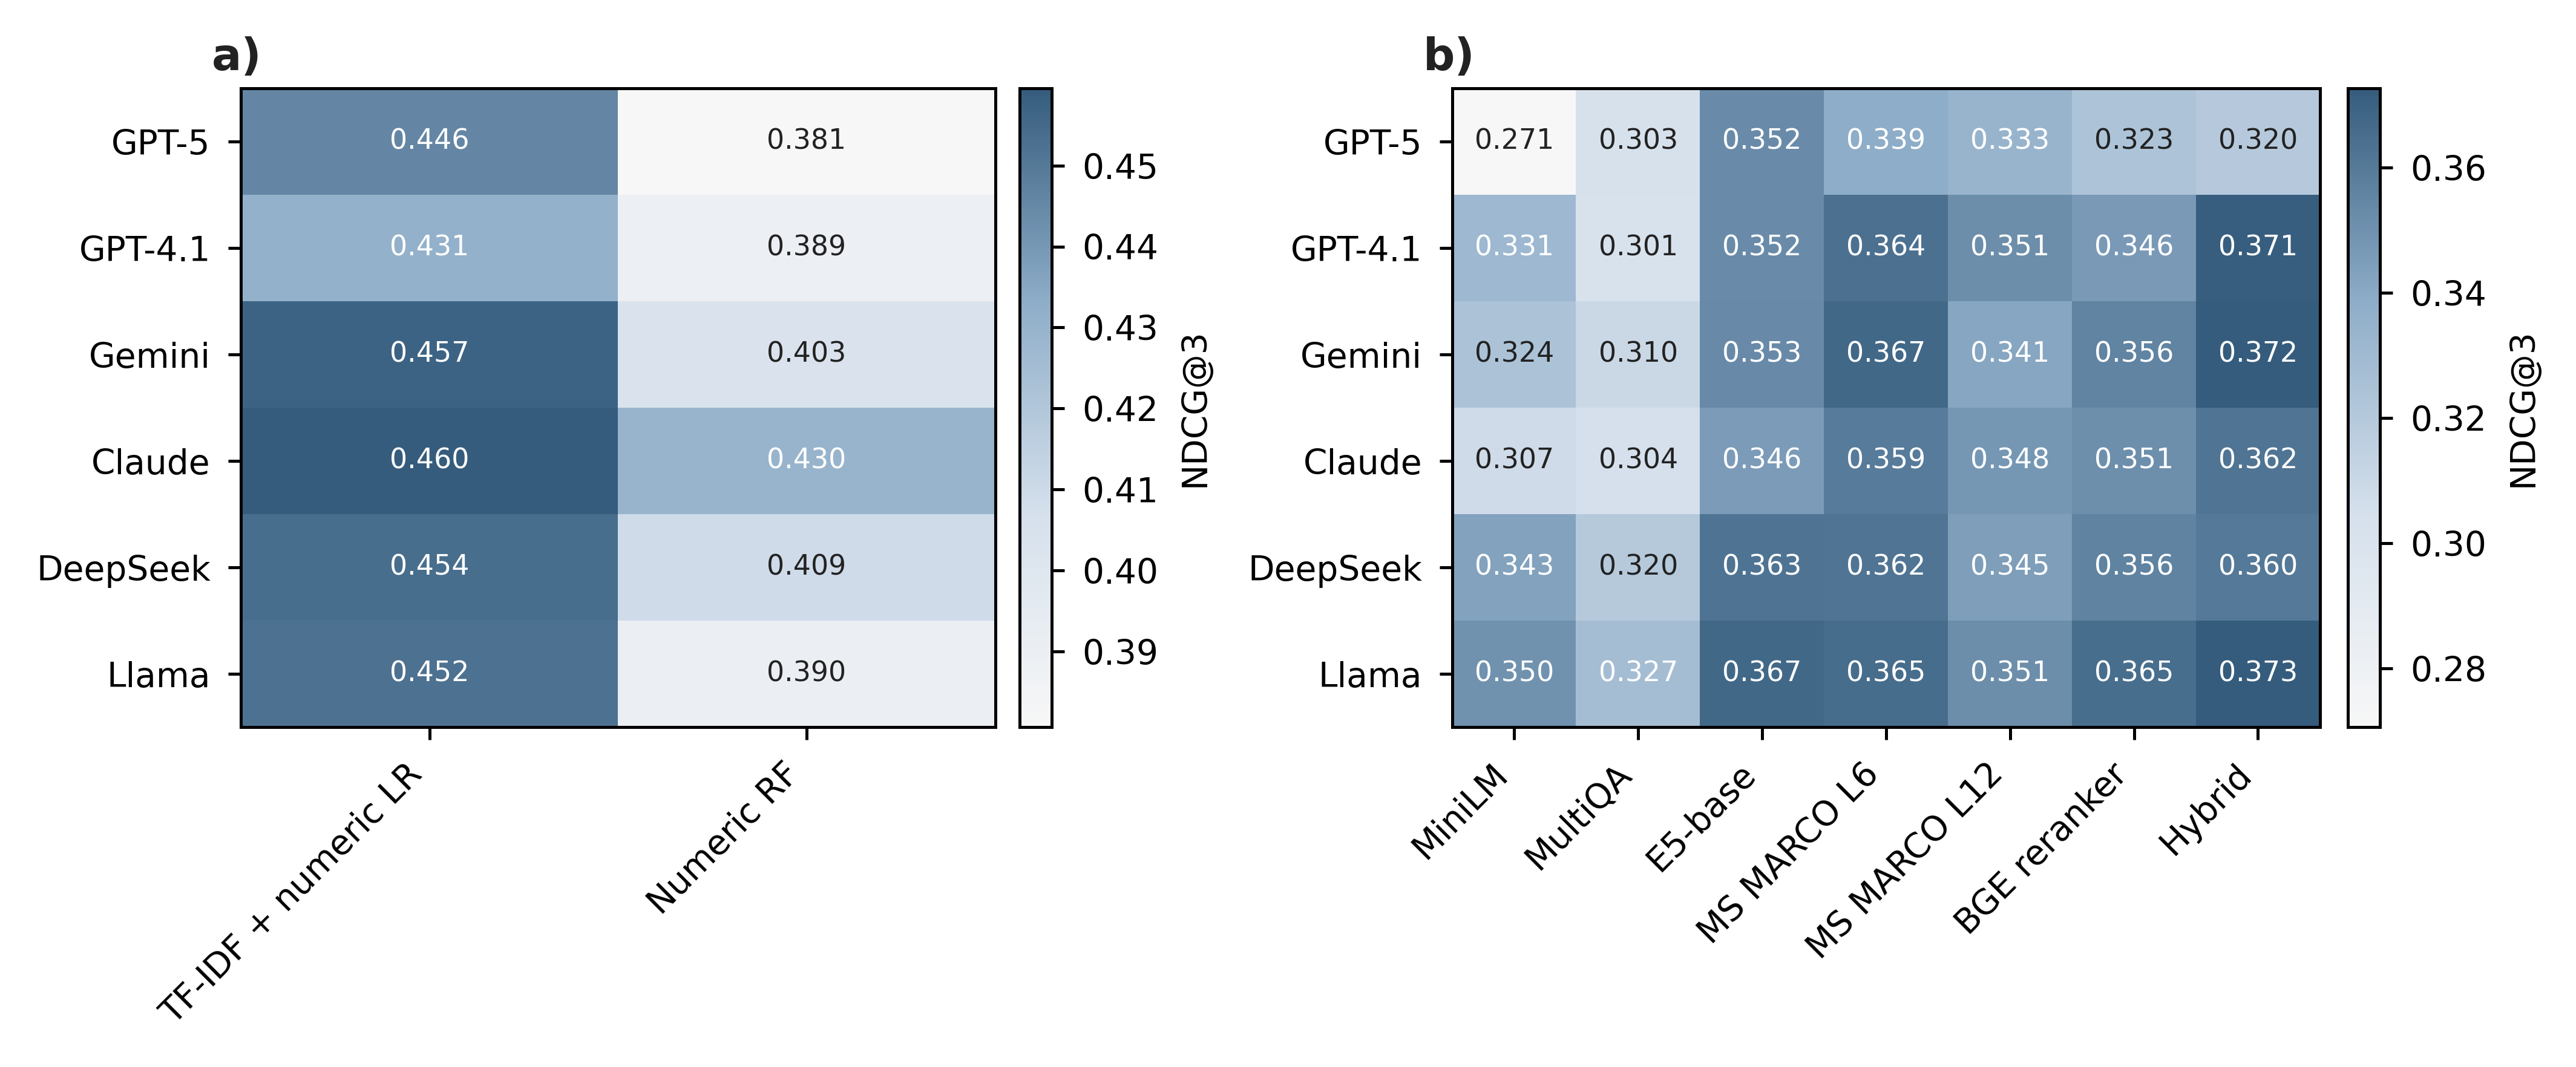

In [8]:
if cross_model_metrics is not None and neural_query_all is not None:
    trained = cross_model_metrics.pivot_table(index="label_model", columns="baseline_model", values="ndcg@3", aggfunc="mean")
    trained = trained.loc[[m for m in MODEL_ORDER if m in trained.index]]
    trained_cols = [c for c in ["textnum_tfidf_logreg", "text_tfidf_logreg", "numeric_random_forest", "numeric_extra_trees", "numeric_xgboost", "numeric_logreg"] if c in trained.columns]
    trained = trained[trained_cols]

    neural = neural_query_all[neural_query_all["score_model"] != "tfidf_compact_cosine"].pivot_table(index="label_model", columns="score_model", values="ndcg@3", aggfunc="mean")
    neural = neural.loc[[m for m in MODEL_ORDER if m in neural.index]]
    neural_cols = [c for c in ["embed_minilm_l6_cosine", "embed_multiqa_minilm_cosine", "embed_e5_base_cosine", "rerank_msmarco_minilm_l6", "rerank_msmarco_minilm_l12", "rerank_bge_base", "hybrid_all_available"] if c in neural.columns]
    neural = neural[neural_cols]

    trained.to_csv(TABLE_DIR / "supp_figS1_trained_ml_cross_model_ndcg_matrix.csv")
    neural.to_csv(TABLE_DIR / "supp_figS1_pretrained_neural_cross_model_ndcg_matrix.csv")

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_170MM, 3.2), gridspec_kw={"width_ratios":[1.0, 1.15]})
    fig.subplots_adjust(left=0.10, right=0.985, bottom=0.31, top=0.86, wspace=0.45)
    d1 = trained.to_numpy(dtype=float)
    im1 = draw_heatmap(axes[0], d1, [model_label(x) for x in trained.index], [method_label(x) for x in trained.columns], vmin=np.nanmin(d1), vmax=np.nanmax(d1))
    c1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.03); c1.set_label("NDCG@3", fontsize=6.8)
    d2 = neural.to_numpy(dtype=float)
    im2 = draw_heatmap(axes[1], d2, [model_label(x) for x in neural.index], [method_label(x) for x in neural.columns], vmin=np.nanmin(d2), vmax=np.nanmax(d2))
    c2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.03); c2.set_label("NDCG@3", fontsize=6.8)
    add_aligned_panel_labels(fig, axes, ["a", "b"])
    save_figure(fig, "supp_figS1_full_robustness_matrices_170mm", "supplementary", "Supplementary Figure S1. Full cross-model robustness matrices. a) Trained ML baselines evaluated against each LLM-specific ranking label. b) Off-the-shelf pretrained neural retrieval and reranker baselines evaluated against the same LLM-specific ranking labels.", "cross_model_robustness_metrics; pretrained_neural_query_metrics")
    plt.show()
else:
    print("Skipping Supplementary Figure S1: missing cross-model or neural metrics.")


# Supplementary Table S2 — Full GPT-5 trained-ML leaderboard

In [9]:
rows = []
for model_name in gpt5_metrics_valid.index:
    rows.append({
        "Model": method_label(model_name),
        "Raw model key": model_name,
        "Valid AUROC ↑": float(gpt5_metrics_valid.loc[model_name, "AUROC"]) if "AUROC" in gpt5_metrics_valid.columns else np.nan,
        "Valid AUPRC ↑": float(gpt5_metrics_valid.loc[model_name, "AUPRC"]) if "AUPRC" in gpt5_metrics_valid.columns else np.nan,
        "Valid F1 ↑": float(gpt5_metrics_valid.loc[model_name, "F1"]) if "F1" in gpt5_metrics_valid.columns else np.nan,
        "Valid NDCG@3 ↑": float(gpt5_query_metrics_valid.loc[model_name, "ndcg@3"]) if model_name in gpt5_query_metrics_valid.index and "ndcg@3" in gpt5_query_metrics_valid.columns else np.nan,
        "Valid SOV captured@3 ↑": float(gpt5_query_metrics_valid.loc[model_name, "sov_captured@3"]) if model_name in gpt5_query_metrics_valid.index and "sov_captured@3" in gpt5_query_metrics_valid.columns else np.nan,
        "Valid top-1 hit@3 ↑": float(gpt5_query_metrics_valid.loc[model_name, "top1_hit@3"]) if model_name in gpt5_query_metrics_valid.index and "top1_hit@3" in gpt5_query_metrics_valid.columns else np.nan,
        "Valid mean true position@3 ↓": float(gpt5_query_metrics_valid.loc[model_name, "mean_true_position@3"]) if model_name in gpt5_query_metrics_valid.index and "mean_true_position@3" in gpt5_query_metrics_valid.columns else np.nan,
        "Test AUPRC ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "AUPRC"),
        "Test NDCG@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "NDCG@3"),
        "Test SOV captured@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "SOV captured@3"),
        "Test top-1 hit@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "Top-1 hit@3"),
        "Test mean true position@3 ↓": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "Mean true position@3"),
    })
leaderboard = pd.DataFrame(rows).sort_values("Valid NDCG@3 ↑", ascending=False)
leaderboard.to_csv(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard_raw.csv", index=False)
round_table_for_csv(leaderboard).to_csv(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv", index=False)

higher_cols = [c for c in leaderboard.columns if "↑" in c]
latex_s2 = best_second_format_latex(leaderboard.drop(columns=["Raw model key"]), higher_cols)
save_latex_table(
    latex_s2,
    TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.tex",
    "Full GPT-5 trained-ML leaderboard with provider-style visibility proxies. Higher values are better except mean true position, where lower values indicate earlier true ranks among predicted top-3 products.",
    "tab:egeo_full_gpt5_leaderboard"
)
display(round_table_for_csv(leaderboard))


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS2_full_gpt5_trained_ml_leaderboard.tex


,Model,Raw model key,Valid AUROC ↑,Valid AUPRC ↑,Valid F1 ↑,Valid NDCG@3 ↑,Valid SOV captured@3 ↑,Valid top-1 hit@3 ↑,Valid mean true position@3 ↓,Test AUPRC ↑,Test NDCG@3 ↑,Test SOV captured@3 ↑,Test top-1 hit@3 ↑,Test mean true position@3 ↓
0,TF-IDF + numeric LR,textnum_tfidf_logreg,0.615,0.405,0.442,0.446,0.388,0.543,4.646,0.400,0.442,0.379,0.497,4.610
2,TF-IDF + numeric SGD,textnum_tfidf_sgd_logloss,0.597,0.386,0.156,0.436,0.380,0.520,4.682,0.383,0.423,0.368,0.464,4.724
1,TF-IDF LR,text_tfidf_logreg,0.608,0.399,0.428,0.433,0.383,0.531,4.688,0.387,0.425,0.370,0.466,4.696
3,TF-IDF SVD + numeric LR,textsvd_num_logreg,0.597,0.381,0.445,0.417,0.370,0.497,4.799,0.382,0.425,0.371,0.479,4.695
4,Numeric ExtraTrees,numeric_extra_trees,0.581,0.375,0.288,0.392,0.356,0.452,4.872,0.380,0.400,0.354,0.429,4.862
6,Numeric XGBoost,numeric_xgboost,0.564,0.360,0.082,0.377,0.347,0.423,5.009,0.359,0.381,0.344,0.407,5.009
5,Numeric RF,numeric_random_forest,0.578,0.372,0.229,0.377,0.350,0.436,4.970,0.377,0.402,0.355,0.431,4.865
9,Numeric LR,numeric_logreg,0.565,0.353,0.407,0.376,0.355,0.464,4.951,0.362,0.387,0.348,0.423,4.962
8,Numeric LightGBM,numeric_lightgbm,0.562,0.355,0.371,0.367,0.344,0.421,4.997,0.360,0.384,0.346,0.414,4.974
7,Numeric HGB,numeric_hist_gradient_boosting,0.563,0.355,0.007,0.358,0.341,0.413,5.072,0.355,0.375,0.345,0.423,5.025


# Supplementary Table S3 — Feature diagnostics

This table is based on **traditional trained ML feature diagnostics**, not pretrained neural embeddings/rerankers.


In [10]:

feature_table = None
imp_df = None
if feature_importance_summary is not None:
    imp_df = feature_importance_summary.rename(columns={"importance_norm": "Importance (%)"}).copy()

# FIX: recompute high-low z from valid_split for exactly the features present in importance table.
# This avoids NaN caused by outer-merging a narrow precomputed profile table with a wider importance table.
diff_df = None
if imp_df is not None and valid_split is not None and "rank" in valid_split.columns:
    importance_features = [str(f) for f in imp_df["feature"].dropna().unique()]
    available_features = [f for f in importance_features if f in valid_split.columns]
    if len(available_features) > 0:
        prof = valid_split.copy()
        prof["rank_group"] = pd.cut(
            pd.to_numeric(prof["rank"], errors="coerce"),
            bins=[0, 3, 7, 10],
            labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"],
            include_lowest=True,
        )
        z = prof[available_features].apply(pd.to_numeric, errors="coerce")
        std = z.std(ddof=0).replace(0, np.nan)
        z = (z - z.mean()) / std
        z["rank_group"] = prof["rank_group"]
        profile_table = z.groupby("rank_group", observed=False)[available_features].mean()
        high_label = next((idx for idx in profile_table.index if "High" in str(idx)), None)
        low_label = next((idx for idx in profile_table.index if "Low" in str(idx)), None)
        if high_label is not None and low_label is not None:
            diff_df = (
                profile_table.loc[high_label] - profile_table.loc[low_label]
            ).rename("High-low z").reset_index().rename(columns={"index": "feature"})
            profile_table.to_csv(TABLE_DIR / "supp_tableS3_recomputed_rank_group_profiles.csv")
            print(f"Recomputed high-low profile for {len(available_features)} importance features.")

# Fallback to older profile table only if recomputation was not possible.
if diff_df is None and rank_group_profiles is not None:
    high_label = next((idx for idx in rank_group_profiles.index if "High" in str(idx)), None)
    low_label = next((idx for idx in rank_group_profiles.index if "Low" in str(idx)), None)
    if high_label is not None and low_label is not None:
        diff_df = (rank_group_profiles.loc[high_label] - rank_group_profiles.loc[low_label]).rename("High-low z").reset_index().rename(columns={"index": "feature"})
        print("Used existing rank_group_profiles fallback.")

if imp_df is not None and diff_df is not None:
    feature_table = imp_df.merge(diff_df, on="feature", how="left")
elif imp_df is not None:
    feature_table = imp_df.copy()
    feature_table["High-low z"] = np.nan
elif existing_s3 is not None:
    # Fallback when the original feature-importance CSV was not uploaded but S3 exists.
    # We keep the existing importance column, infer raw feature names, and recompute High-low z.
    feature_table_final = existing_s3.copy()
    reverse_feature_map = {v: k for k, v in FEATURE_NAME_MAP.items()}

    def infer_raw_feature_name(display_name):
        s = str(display_name)
        if s in reverse_feature_map:
            return reverse_feature_map[s]
        # Try exact lower-case reverse map.
        lower_reverse = {str(v).lower(): k for k, v in FEATURE_NAME_MAP.items()}
        if s.lower() in lower_reverse:
            return lower_reverse[s.lower()]
        return s.strip().lower().replace("/", "_").replace("-", "_").replace(" ", "_")

    if valid_split is not None and "rank" in valid_split.columns and "Feature" in feature_table_final.columns:
        raw_features = [infer_raw_feature_name(x) for x in feature_table_final["Feature"]]
        available = [f for f in raw_features if f in valid_split.columns]
        if len(available) > 0:
            prof = valid_split.copy()
            prof["rank_group"] = pd.cut(
                pd.to_numeric(prof["rank"], errors="coerce"),
                bins=[0, 3, 7, 10],
                labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"],
                include_lowest=True,
            )
            z = prof[available].apply(pd.to_numeric, errors="coerce")
            std = z.std(ddof=0).replace(0, np.nan)
            z = (z - z.mean()) / std
            z["rank_group"] = prof["rank_group"]
            profile_table = z.groupby("rank_group", observed=False)[available].mean()
            high_label = next((idx for idx in profile_table.index if "High" in str(idx)), None)
            low_label = next((idx for idx in profile_table.index if "Low" in str(idx)), None)
            if high_label is not None and low_label is not None:
                diff_series = profile_table.loc[high_label] - profile_table.loc[low_label]
                recomputed_vals = []
                for raw in raw_features:
                    recomputed_vals.append(float(diff_series[raw]) if raw in diff_series.index else np.nan)
                feature_table_final["High-low z"] = recomputed_vals

                def fallback_direction_label(x, eps=1e-10):
                    if pd.isna(x):
                        return "Not profiled"
                    if x > eps:
                        return "Higher in high-visibility rows"
                    if x < -eps:
                        return "Higher in low-visibility rows"
                    return "No meaningful difference"
                feature_table_final["Direction"] = feature_table_final["High-low z"].map(fallback_direction_label)
                print("Recomputed High-low z for existing S3 fallback rows.")
    feature_table = None
else:
    feature_table = None

if feature_table is not None:
    feature_table["abs_high_low_z"] = pd.to_numeric(feature_table["High-low z"], errors="coerce").abs()
    feature_table = feature_table.sort_values(["Importance (%)", "abs_high_low_z"], ascending=[False, False]).head(15).copy()
    feature_table["Feature"] = feature_table["feature"].map(lambda x: FEATURE_NAME_MAP.get(str(x), str(x).replace("_", " ")))

    def direction_label(x, eps=1e-10):
        if pd.isna(x):
            return "Not profiled"
        if x > eps:
            return "Higher in high-visibility rows"
        if x < -eps:
            return "Higher in low-visibility rows"
        return "No meaningful difference"

    feature_table["Direction"] = feature_table["High-low z"].map(direction_label)
    feature_table_final = feature_table[["Feature", "Importance (%)", "High-low z", "Direction"]]

if "feature_table_final" in globals() and feature_table_final is not None:
    feature_table_final.to_csv(TABLE_DIR / "supp_tableS3_feature_diagnostics_raw.csv", index=False)
    round_table_for_csv(feature_table_final).to_csv(TABLE_DIR / "supp_tableS3_feature_diagnostics.csv", index=False)
    save_latex_table(round_table_for_csv(feature_table_final), TABLE_DIR / "supp_tableS3_feature_diagnostics.tex", "Feature diagnostics from trained traditional ML models.", "tab:egeo_feature_diagnostics")
    display(round_table_for_csv(feature_table_final))
else:
    print("Skipping Supplementary Table S3: missing feature diagnostic inputs.")


Recomputed high-low profile for 29 importance features.
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS3_feature_diagnostics.tex


,Feature,Importance (%),High-low z,Direction
0,TF-IDF query-product similarity,5.678,-0.012,Higher in low-visibility rows
1,Product text length,5.237,-0.063,Higher in low-visibility rows
2,Query-product overlap,5.120,-0.002,Higher in low-visibility rows
3,rating number,4.996,0.103,Higher in high-visibility rows
4,Query-feature overlap,4.919,0.035,Higher in high-visibility rows
5,Query text length,4.887,0.000,No meaningful difference
6,features len words,4.851,-0.009,Higher in low-visibility rows
7,Query-title overlap,4.833,0.009,Higher in high-visibility rows
8,Details text length,4.727,0.137,Higher in high-visibility rows
9,Average rating,4.715,0.173,Higher in high-visibility rows


# Optional Supplementary Figure S2 — Visual feature table heatmap

Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.svg


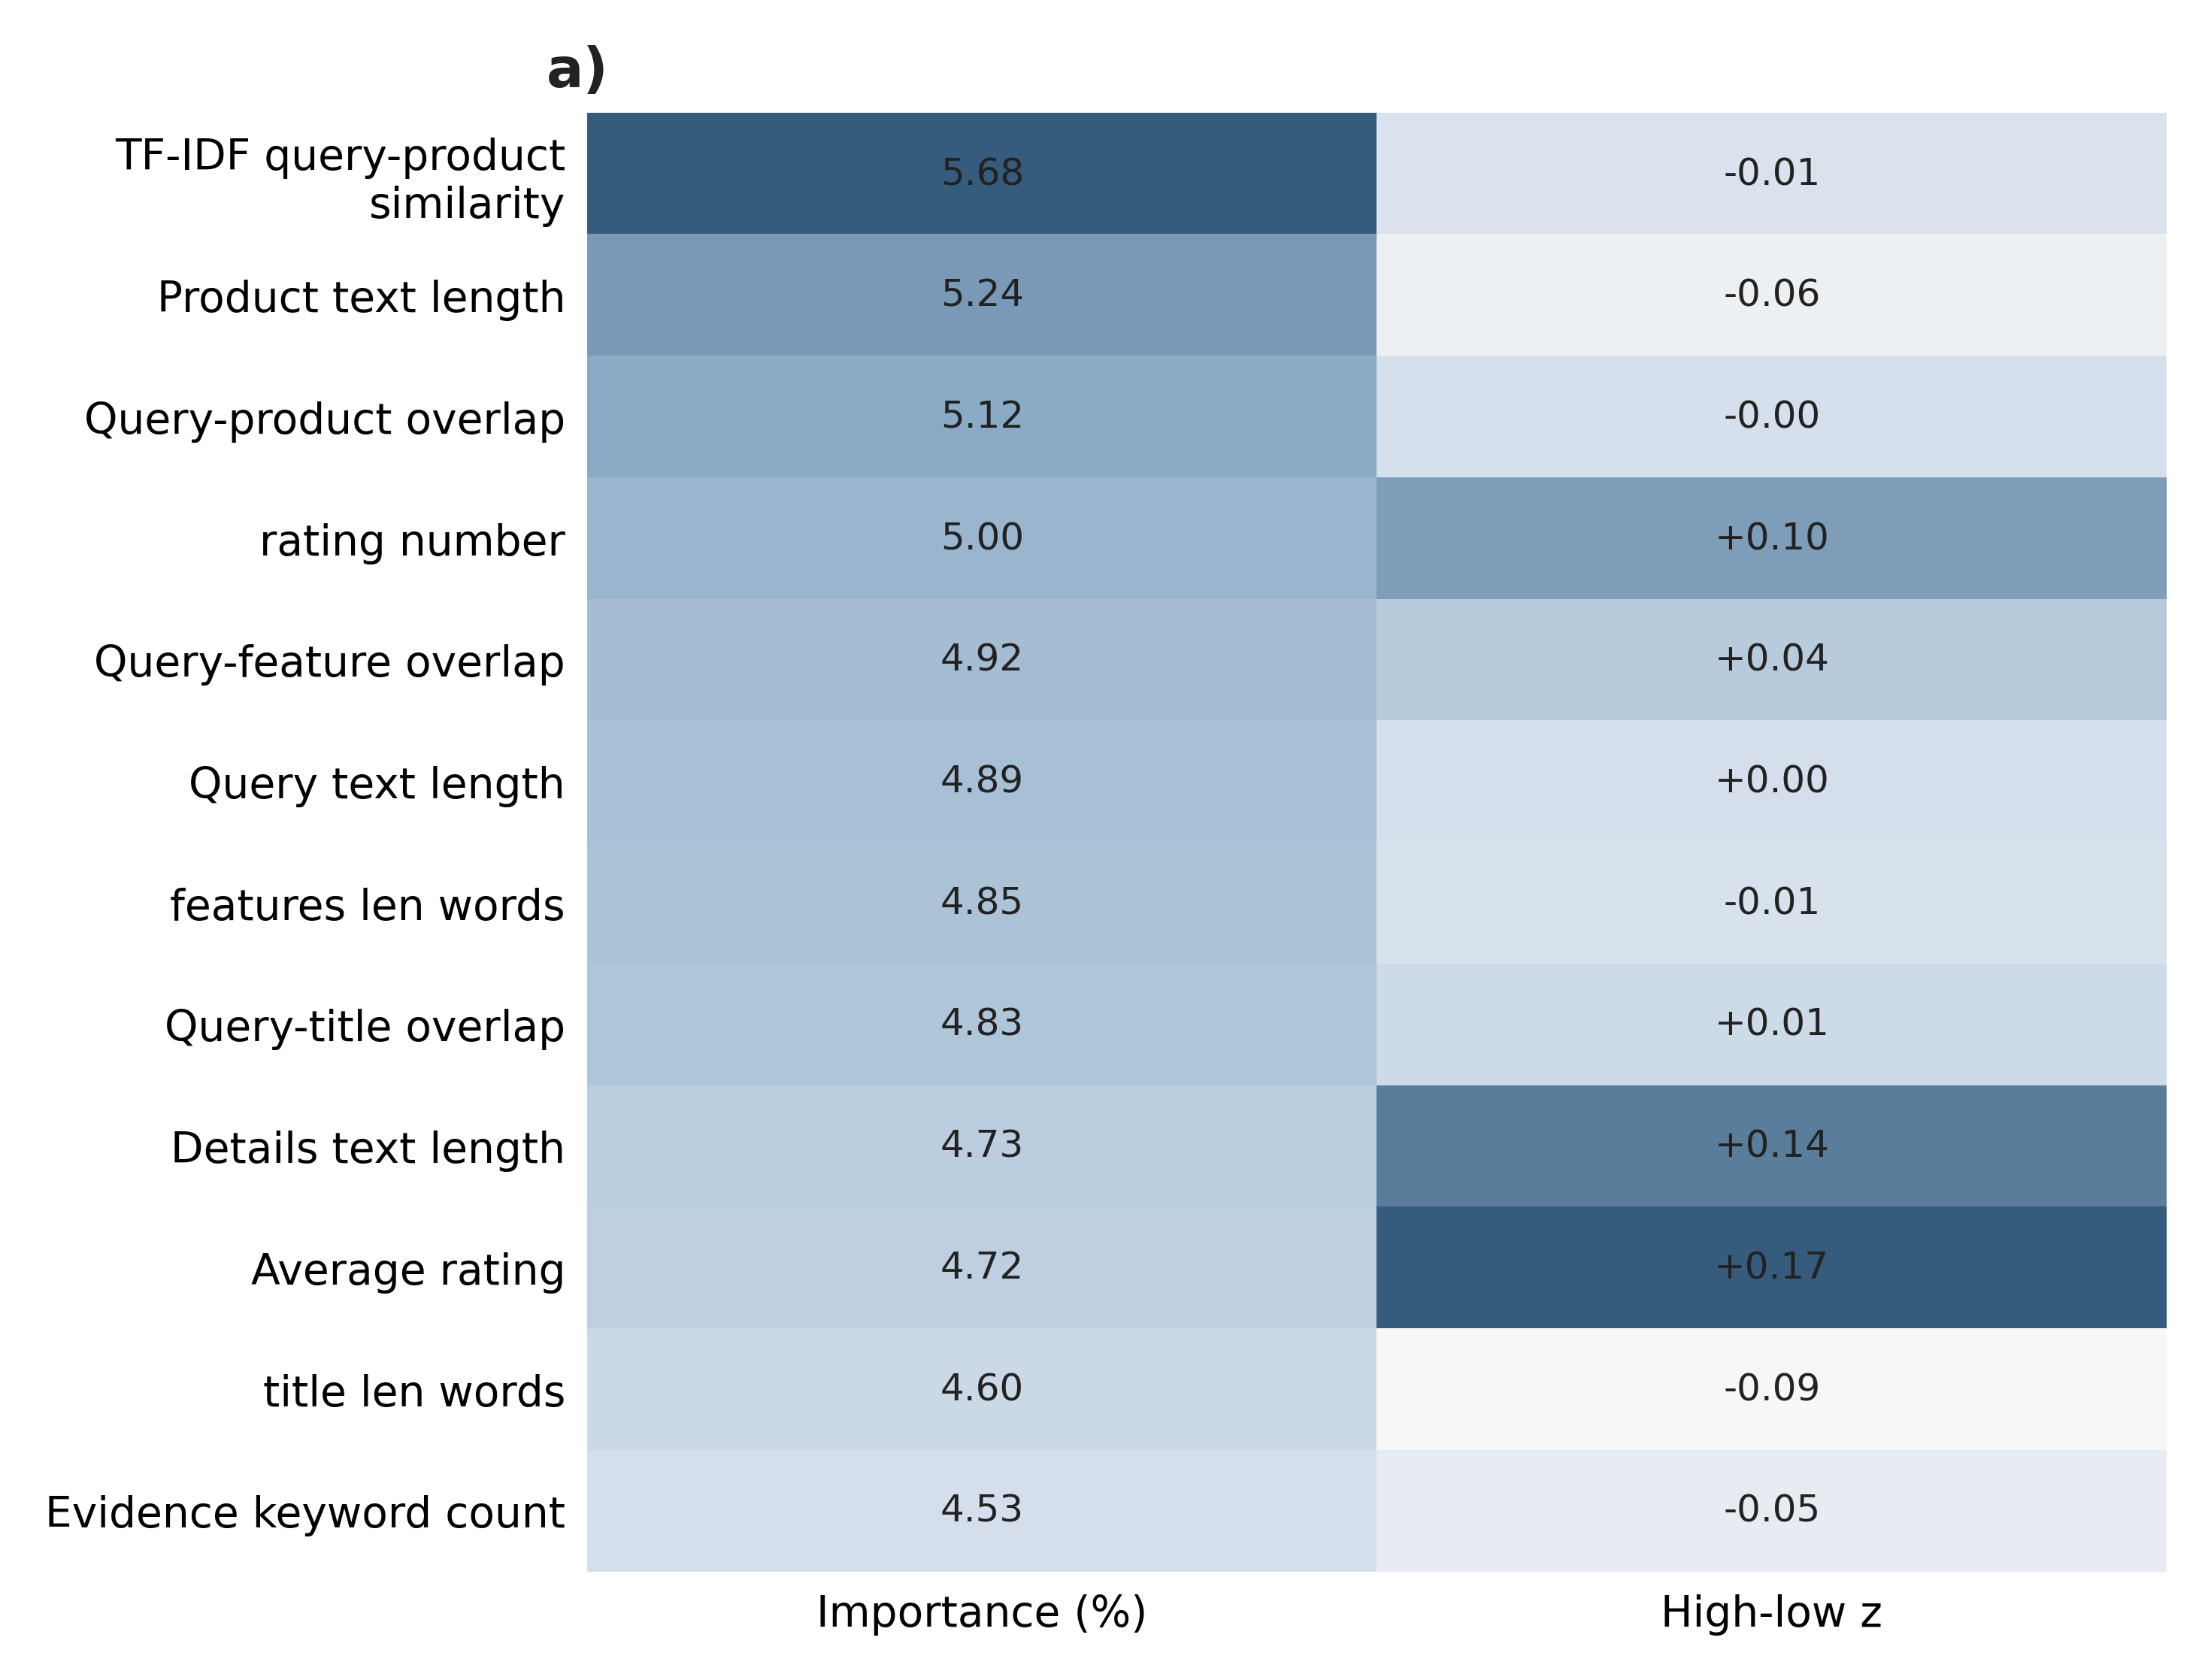

In [11]:
if "feature_table_final" in globals() and feature_table_final is not None:
    plot_df = feature_table_final.head(12).copy()
    numeric_cols = ["Importance (%)", "High-low z"]
    display_df = plot_df.set_index("Feature")[numeric_cols]
    color_data = display_df.copy()
    for col in numeric_cols:
        vals = pd.to_numeric(color_data[col], errors="coerce")
        if col == "High-low z":
            max_abs = np.nanmax(np.abs(vals))
            color_data[col] = vals / max_abs if max_abs and np.isfinite(max_abs) else vals
        else:
            mn, mx = np.nanmin(vals), np.nanmax(vals)
            color_data[col] = (vals - mn) / (mx - mn) if mx > mn else vals * 0
    arr = np.nan_to_num(color_data.to_numpy(dtype=float), nan=0.0)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH_85MM * 1.35, 4.2))
    ax.imshow(arr, aspect="auto", cmap=HEATMAP_CMAP)
    ax.set_xticks(np.arange(len(numeric_cols))); ax.set_xticklabels(numeric_cols)
    ax.set_yticks(np.arange(len(display_df.index))); ax.set_yticklabels([fill(x, width=25) for x in display_df.index])
    for i in range(display_df.shape[0]):
        for j, col in enumerate(numeric_cols):
            val = display_df.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}" if col == "Importance (%)" else f"{val:+.2f}", ha="center", va="center", fontsize=6.0, color=COLORS["black"])
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values(): spine.set_visible(False)
    add_aligned_panel_labels(fig, [ax], ["a"], dx=0.02, dy=0.008)
    save_figure(fig, "optional_supp_figS2_feature_diagnostic_table_heatmap_85mm", "supplementary", "Optional Supplementary Figure S2. Visual table-style heatmap for feature diagnostics from traditional trained ML models.", "feature_importance_gpt5_all_tree_models; rank_group_standardized_feature_profiles or fallback")
    plt.show()
else:
    print("Skipping optional Supplementary Figure S2.")


## Save manifest, captions, and recommended output order

In [12]:
manifest = pd.DataFrame(figure_manifest)
manifest_path = TABLE_DIR / "egeo_benchmark_final_figure_manifest.csv"
manifest.to_csv(manifest_path, index=False)

caption_path = RESULTS_DIR / "egeo_benchmark_final_figure_captions.md"
with open(caption_path, "w", encoding="utf-8") as f:
    f.write("# E-GEO benchmark-style final figure captions\n\n")
    for _, row in manifest.iterrows():
        f.write(f"## {row['figure_id']}\n\n")
        f.write(f"**Category:** {row['category']}\n\n")
        f.write(f"**Caption:** {row['caption']}\n\n")
        f.write(f"**Source files:** {row['source_files']}\n\n")
        f.write(f"**PDF:** `{row['pdf_path']}`\n\n")
        f.write(f"**SVG:** `{row['svg_path']}`\n\n")
        f.write(f"**PNG:** `{row['png_path']}`\n\n")

recommended = pd.DataFrame([
    {"order":1, "item":"main_fig1_visibility_prediction_single_170mm", "placement":"Main Figure 1", "type":"figure"},
    {"order":2, "item":"supp_tableS1_benchmark_summary.csv/.tex", "placement":"Supplementary Table S1: benchmark + provider-style metrics", "type":"table"},
    {"order":3, "item":"supp_figS1_full_robustness_matrices_170mm", "placement":"Supplementary Figure S1", "type":"figure"},
    {"order":4, "item":"supp_tableS2_full_gpt5_trained_ml_leaderboard.csv/.tex", "placement":"Supplementary Table S2: full GPT-5 leaderboard + provider-style metrics", "type":"table"},
    {"order":5, "item":"supp_tableS3_feature_diagnostics.csv/.tex", "placement":"Supplementary Table S3", "type":"table"},
    {"order":6, "item":"optional_supp_figS2_feature_diagnostic_table_heatmap_85mm", "placement":"Optional Supplementary Figure S2", "type":"optional figure"},
])
recommended_path = TABLE_DIR / "egeo_benchmark_final_output_order.csv"
recommended.to_csv(recommended_path, index=False)

print("Saved manifest:", manifest_path)
print("Saved captions:", caption_path)
print("Saved recommended order:", recommended_path)
display(manifest)
display(recommended)


Saved manifest: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/egeo_benchmark_final_figure_manifest.csv
Saved captions: /content/drive/MyDrive/Finance Research/E-GEO-ML/results/egeo_benchmark_final_figure_captions.md
Saved recommended order: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/egeo_benchmark_final_output_order.csv


,figure_id,category,png_path,pdf_path,svg_path,caption,source_files
0,main_fig1_visibility_prediction_single_170mm,main,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Figure 1. Predicting LLM shopping visibility f...,gpt5 validation/test metrics; cross_model_robu...
1,supp_figS1_full_robustness_matrices_170mm,supplementary,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Supplementary Figure S1. Full cross-model robu...,cross_model_robustness_metrics; pretrained_neu...
2,optional_supp_figS2_feature_diagnostic_table_h...,supplementary,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Optional Supplementary Figure S2. Visual table...,feature_importance_gpt5_all_tree_models; rank_...


,order,item,placement,type
0,1,main_fig1_visibility_prediction_single_170mm,Main Figure 1,figure
1,2,supp_tableS1_benchmark_summary.csv/.tex,Supplementary Table S1: benchmark + provider-s...,table
2,3,supp_figS1_full_robustness_matrices_170mm,Supplementary Figure S1,figure
3,4,supp_tableS2_full_gpt5_trained_ml_leaderboard....,Supplementary Table S2: full GPT-5 leaderboard...,table
4,5,supp_tableS3_feature_diagnostics.csv/.tex,Supplementary Table S3,table
5,6,optional_supp_figS2_feature_diagnostic_table_h...,Optional Supplementary Figure S2,optional figure


## Final provider-style takeaway — what the XLSX metrics add

This final check turns the provider-style proxies into an interpretable comparison. It answers the question: **does the best trained model only improve NDCG/AUPRC, or does it also recover more provider-aligned visibility such as share-of-voice, first-position visibility, and better mention position?**

In [13]:

# ------------------------------------------------------------
# Final provider-style comparison and interpretation
# ------------------------------------------------------------
# This cell is intentionally placed at the end so the last notebook output is
# not only a file manifest, but the actual "so what" result of adding XLSX-inspired metrics.

summary_path_raw = TABLE_DIR / "supp_tableS1_benchmark_summary_raw.csv"
summary_path_round = TABLE_DIR / "supp_tableS1_benchmark_summary.csv"

if summary_path_raw.exists():
    provider_summary = pd.read_csv(summary_path_raw)
elif summary_path_round.exists():
    provider_summary = pd.read_csv(summary_path_round)
else:
    raise FileNotFoundError("Missing Supplementary Table S1. Run the earlier Table S1 cell first.")

# Columns that carry the actual provider-aligned argument.
key_cols = [
    "Family",
    "Representative method",
    "GPT-5 val NDCG@3 ↑",
    "GPT-5 val AUPRC ↑",
    "GPT-5 val SOV captured@3 ↑",
    "GPT-5 val top-1 hit@3 ↑",
    "GPT-5 val mean true position@3 ↓",
    "GPT-5 test NDCG@3 ↑",
    "GPT-5 test AUPRC ↑",
    "Cross-model mean NDCG@3 ↑",
    "Cross-model mean SOV captured@3 ↑",
]
key_cols = [c for c in key_cols if c in provider_summary.columns]
provider_view = provider_summary[key_cols].copy()

# Numeric conversion for robust delta calculation.
for c in provider_view.columns:
    if c not in ["Family", "Representative method"]:
        provider_view[c] = pd.to_numeric(provider_view[c], errors="coerce")

# Make deltas relative to Random and Lexical, because this is the clearest way
# to show what the provider-style metrics add beyond standard NDCG/AUPRC.
def first_family_row(df, family_name):
    d = df[df["Family"].astype(str).str.lower().eq(family_name.lower())]
    return d.iloc[0] if len(d) else None

random_row = first_family_row(provider_view, "Random")
lexical_row = first_family_row(provider_view, "Lexical")

comparison = provider_view.copy()
for metric in [
    "GPT-5 val NDCG@3 ↑",
    "GPT-5 val AUPRC ↑",
    "GPT-5 val SOV captured@3 ↑",
    "GPT-5 val top-1 hit@3 ↑",
    "GPT-5 val mean true position@3 ↓",
    "GPT-5 test NDCG@3 ↑",
    "GPT-5 test AUPRC ↑",
    "Cross-model mean NDCG@3 ↑",
    "Cross-model mean SOV captured@3 ↑",
]:
    if metric in comparison.columns:
        if random_row is not None and pd.notna(random_row.get(metric, np.nan)):
            comparison[f"Δ vs Random: {metric}"] = comparison[metric] - random_row[metric]
        if lexical_row is not None and pd.notna(lexical_row.get(metric, np.nan)):
            comparison[f"Δ vs Lexical: {metric}"] = comparison[metric] - lexical_row[metric]

# Save clean outputs.
provider_view.to_csv(TABLE_DIR / "provider_style_visibility_summary.csv", index=False)
comparison.to_csv(TABLE_DIR / "provider_style_visibility_comparison_deltas.csv", index=False)

# Identify best rows for the key provider-aligned metrics.
def best_row(metric, higher_is_better=True):
    if metric not in provider_view.columns:
        return None
    d = provider_view.dropna(subset=[metric]).copy()
    if d.empty:
        return None
    idx = d[metric].idxmax() if higher_is_better else d[metric].idxmin()
    return d.loc[idx]

best_ndcg = best_row("GPT-5 val NDCG@3 ↑", True)
best_sov = best_row("GPT-5 val SOV captured@3 ↑", True)
best_top1 = best_row("GPT-5 val top-1 hit@3 ↑", True)
best_pos = best_row("GPT-5 val mean true position@3 ↓", False)

lines = []
lines.append("# Provider-style visibility interpretation")
lines.append("")
lines.append("The XLSX-inspired metrics are not new ML input features. They are evaluation proxies that translate commercial AI-visibility concepts into the public E-GEO ranking setting.")
lines.append("")
if best_ndcg is not None:
    lines.append(f"- Best GPT-5 validation NDCG@3: **{best_ndcg['Family']}** ({best_ndcg['Representative method']}), {best_ndcg['GPT-5 val NDCG@3 ↑']:.3f}.")
if best_sov is not None:
    lines.append(f"- Best provider-style share-of-voice captured@3: **{best_sov['Family']}** ({best_sov['Representative method']}), {best_sov['GPT-5 val SOV captured@3 ↑']:.3f}.")
if best_top1 is not None:
    lines.append(f"- Best first-position visibility proxy, top-1 hit@3: **{best_top1['Family']}** ({best_top1['Representative method']}), {best_top1['GPT-5 val top-1 hit@3 ↑']:.3f}.")
if best_pos is not None:
    lines.append(f"- Best average mention-position proxy, mean true position@3: **{best_pos['Family']}** ({best_pos['Representative method']}), {best_pos['GPT-5 val mean true position@3 ↓']:.3f}; lower is better.")
lines.append("")
lines.append("Interpretation: the provider-style metrics do not change the training target; they make the same benchmark more meaningful for GEO/AI-visibility research by showing whether a method recovers not only top-3 labels, but also share-of-voice, first-position visibility, and earlier true ranking position.")

interpretation_text = "\n".join(lines)
interpretation_path = RESULTS_DIR / "provider_style_visibility_interpretation.md"
with open(interpretation_path, "w", encoding="utf-8") as f:
    f.write(interpretation_text + "\n")

print("Saved provider-style summary:", TABLE_DIR / "provider_style_visibility_summary.csv")
print("Saved provider-style comparison deltas:", TABLE_DIR / "provider_style_visibility_comparison_deltas.csv")
print("Saved interpretation:", interpretation_path)
print("\n" + interpretation_text)

print("\nProvider-style summary:")
display(round_table_for_csv(provider_view))

# Display a compact delta table, not every column, so the final output is readable.
delta_cols = [
    "Family", "Representative method",
    "Δ vs Random: GPT-5 val NDCG@3 ↑",
    "Δ vs Random: GPT-5 val AUPRC ↑",
    "Δ vs Random: GPT-5 val SOV captured@3 ↑",
    "Δ vs Random: GPT-5 val top-1 hit@3 ↑",
    "Δ vs Random: GPT-5 val mean true position@3 ↓",
    "Δ vs Lexical: GPT-5 val NDCG@3 ↑",
    "Δ vs Lexical: GPT-5 val SOV captured@3 ↑",
]
delta_cols = [c for c in delta_cols if c in comparison.columns]
print("\nProvider-style deltas:")
display(round_table_for_csv(comparison[delta_cols]))


Saved provider-style summary: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/provider_style_visibility_summary.csv
Saved provider-style comparison deltas: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/provider_style_visibility_comparison_deltas.csv
Saved interpretation: /content/drive/MyDrive/Finance Research/E-GEO-ML/results/provider_style_visibility_interpretation.md

# Provider-style visibility interpretation

The XLSX-inspired metrics are not new ML input features. They are evaluation proxies that translate commercial AI-visibility concepts into the public E-GEO ranking setting.

- Best GPT-5 validation NDCG@3: **Text + metadata trained ML** (TF-IDF + numeric LR), 0.446.
- Best provider-style share-of-voice captured@3: **Text + metadata trained ML** (TF-IDF + numeric LR), 0.388.
- Best first-position visibility proxy, top-1 hit@3: **Text + metadata trained ML** (TF-IDF + numeric LR), 0.543.
- Best av

,Family,Representative method,GPT-5 val NDCG@3 ↑,GPT-5 val AUPRC ↑,GPT-5 val SOV captured@3 ↑,GPT-5 val top-1 hit@3 ↑,GPT-5 val mean true position@3 ↓,GPT-5 test NDCG@3 ↑,GPT-5 test AUPRC ↑,Cross-model mean NDCG@3 ↑,Cross-model mean SOV captured@3 ↑
0,Random,Random ranking,0.326,0.310,0.312,0.321,5.336,0.303,0.300,0.309,0.304
1,Lexical,TF-IDF cosine,0.294,0.295,0.296,0.293,5.525,0.316,0.304,0.325,0.296
2,Pretrained neural,E5-base,0.352,0.320,0.320,0.337,5.223,0.346,0.321,0.356,0.336
3,Numeric-only trained ML,Numeric RF,0.377,0.372,0.350,0.436,4.970,0.402,0.377,0.400,0.357
4,Text + metadata trained ML,TF-IDF + numeric LR,0.446,0.405,0.388,0.543,4.646,0.442,0.400,0.450,0.387



Provider-style deltas:


,Family,Representative method,Δ vs Random: GPT-5 val NDCG@3 ↑,Δ vs Random: GPT-5 val AUPRC ↑,Δ vs Random: GPT-5 val SOV captured@3 ↑,Δ vs Random: GPT-5 val top-1 hit@3 ↑,Δ vs Random: GPT-5 val mean true position@3 ↓,Δ vs Lexical: GPT-5 val NDCG@3 ↑,Δ vs Lexical: GPT-5 val SOV captured@3 ↑
0,Random,Random ranking,0.000,0.000,0.000,0.000,0.000,0.032,0.016
1,Lexical,TF-IDF cosine,-0.032,-0.015,-0.016,-0.028,0.189,0.000,0.000
2,Pretrained neural,E5-base,0.027,0.010,0.008,0.015,-0.113,0.058,0.024
3,Numeric-only trained ML,Numeric RF,0.051,0.062,0.037,0.115,-0.366,0.083,0.054
4,Text + metadata trained ML,TF-IDF + numeric LR,0.120,0.095,0.076,0.222,-0.690,0.152,0.092


In [14]:
# ============================================================
# Final provider-proxy diagnostics: PRINT/DISPLAY ONLY
# No CSV saving, no figure saving
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

# -----------------------------
# 1. Locate split files
# -----------------------------
DATA_DIR = Path(DATA_DIR) if "DATA_DIR" in globals() else Path(".")

candidate_files = {
    "validation": [
        DATA_DIR / "egeo_gpt5_internal_valid_split.csv",
        DATA_DIR / "gpt5_internal_valid_split.csv",
        DATA_DIR / "internal_valid_split.csv",
    ],
    "official_test": [
        DATA_DIR / "egeo_gpt5_official_test_split.csv",
        DATA_DIR / "gpt5_official_test_split.csv",
        DATA_DIR / "official_test_split.csv",
    ],
}

def load_first_existing(paths):
    for p in paths:
        if p.exists():
            return pd.read_csv(p), p
    return None, None

split_frames = []
loaded_paths = {}

for split_name, paths in candidate_files.items():
    df, path = load_first_existing(paths)
    if df is not None:
        df = df.copy()
        df["split"] = split_name
        split_frames.append(df)
        loaded_paths[split_name] = str(path)

if not split_frames:
    raise FileNotFoundError(
        "Could not find validation/test split files. "
        "Check DATA_DIR or file names."
    )

df_all = pd.concat(split_frames, ignore_index=True)

print("Loaded split files:")
for k, v in loaded_paths.items():
    print(f"  {k}: {v}")

print("\nCombined rows:", len(df_all))
display(df_all.head(3))


# -----------------------------
# 2. Ensure proxy columns exist
# -----------------------------
# These are outcome/evaluation proxies derived from observed rank labels.
# They should NOT be used as ML input features.

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

rank_col = find_col(df_all, ["rank", "true_rank", "observed_rank", "position", "rank_position"])
top3_col = find_col(df_all, ["top3", "is_top3", "top_3", "top3_label"])
top1_col = find_col(df_all, ["top1", "is_top1", "top_1", "top1_label"])
query_col = find_col(df_all, ["query", "query_clean", "query_id", "qid", "prompt", "prompt_id"])

if rank_col is None:
    raise ValueError(
        "No rank column found. Need one of: rank, true_rank, observed_rank, position, rank_position."
    )

df_all[rank_col] = pd.to_numeric(df_all[rank_col], errors="coerce")

if top3_col is None:
    df_all["top3_auto"] = (df_all[rank_col] <= 3).astype(int)
    top3_col = "top3_auto"

if top1_col is None:
    df_all["top1_auto"] = (df_all[rank_col] == 1).astype(int)
    top1_col = "top1_auto"

# Row-level provider-style proxies
if "visibility_presence_proxy" not in df_all.columns:
    df_all["visibility_presence_proxy"] = df_all[top3_col].astype(float)

if "first_position_proxy" not in df_all.columns:
    df_all["first_position_proxy"] = df_all[top1_col].astype(float)

if "average_position_proxy" not in df_all.columns:
    df_all["average_position_proxy"] = df_all[rank_col].astype(float)

if "rank_score_proxy" not in df_all.columns:
    # Higher is better. Rank 1 = 1.0, rank 2 = 0.5, rank 3 = 0.333, etc.
    df_all["rank_score_proxy"] = 1.0 / df_all[rank_col].replace(0, np.nan)

# Share-of-voice proxy: normalize inverse-rank score within each query/split.
if "share_of_voice_proxy" not in df_all.columns:
    base = 1.0 / df_all[rank_col].replace(0, np.nan)

    if query_col is not None:
        denom = base.groupby([df_all["split"], df_all[query_col]]).transform("sum")
        df_all["share_of_voice_proxy"] = base / denom.replace(0, np.nan)
    else:
        # fallback: global normalization within split
        denom = base.groupby(df_all["split"]).transform("sum")
        df_all["share_of_voice_proxy"] = base / denom.replace(0, np.nan)

if "top3_share_of_voice_proxy" not in df_all.columns:
    df_all["top3_share_of_voice_proxy"] = (
        df_all["share_of_voice_proxy"] * df_all["visibility_presence_proxy"]
    )

proxy_cols = [
    "rank_score_proxy",
    "share_of_voice_proxy",
    "top3_share_of_voice_proxy",
    "visibility_presence_proxy",
    "average_position_proxy",
    "first_position_proxy",
]

print("\nProxy columns available:")
print(proxy_cols)

print("\nIMPORTANT:")
print("These proxy columns are derived from observed rank/top-k labels.")
print("They are for evaluation/reporting only, not ML input features.")


# -----------------------------
# 3. Proxy definition table
# -----------------------------
proxy_definitions = pd.DataFrame([
    {
        "proxy_column": "visibility_presence_proxy",
        "provider_metric_mapping": "brand_mention_rate / visibility presence",
        "definition": "1 if the product appears in observed top-3 ranking, else 0",
        "interpretation": "Whether a product is visible in the AI shopping answer candidate set",
        "use_as_feature?": "No",
    },
    {
        "proxy_column": "first_position_proxy",
        "provider_metric_mapping": "first-position visibility / top answer presence",
        "definition": "1 if observed rank is 1, else 0",
        "interpretation": "Whether the product is the first visible recommendation",
        "use_as_feature?": "No",
    },
    {
        "proxy_column": "average_position_proxy",
        "provider_metric_mapping": "average_mention_position",
        "definition": "Observed rank position",
        "interpretation": "Lower values mean better AI-answer position",
        "use_as_feature?": "No",
    },
    {
        "proxy_column": "rank_score_proxy",
        "provider_metric_mapping": "position-weighted visibility",
        "definition": "1 / observed rank",
        "interpretation": "Higher score gives more weight to higher answer positions",
        "use_as_feature?": "No",
    },
    {
        "proxy_column": "share_of_voice_proxy",
        "provider_metric_mapping": "share_of_voice",
        "definition": "Inverse-rank score normalized within each query",
        "interpretation": "Approximate share of AI-answer visibility captured by each product",
        "use_as_feature?": "No",
    },
    {
        "proxy_column": "top3_share_of_voice_proxy",
        "provider_metric_mapping": "top-k share_of_voice",
        "definition": "share_of_voice_proxy counted only for observed top-3 products",
        "interpretation": "Visibility share concentrated inside the answer-visible top-3 set",
        "use_as_feature?": "No",
    },
])

display(Markdown("## 1. Provider-style proxy definitions"))
display(proxy_definitions)


# -----------------------------
# 4. Split-level summary
# -----------------------------
summary_rows = []

for split_name, g in df_all.groupby("split"):
    row = {
        "split": split_name,
        "n_rows": len(g),
        "top3_visibility_rate": g["visibility_presence_proxy"].mean(),
        "top1_visibility_rate": g["first_position_proxy"].mean(),
        "mean_observed_position": g["average_position_proxy"].mean(),
        "median_observed_position": g["average_position_proxy"].median(),
        "mean_rank_score_proxy": g["rank_score_proxy"].mean(),
        "mean_share_of_voice_proxy": g["share_of_voice_proxy"].mean(),
        "mean_top3_share_of_voice_proxy": g["top3_share_of_voice_proxy"].mean(),
    }
    summary_rows.append(row)

split_summary = pd.DataFrame(summary_rows)

display(Markdown("## 2. Split-level proxy summary"))
display(split_summary.round(4))


# -----------------------------
# 5. Rank profile
# -----------------------------
rank_profile = (
    df_all
    .groupby(["split", rank_col], dropna=False)[proxy_cols]
    .mean()
    .reset_index()
    .sort_values(["split", rank_col])
)

display(Markdown("## 3. Rank profile: how proxies change by observed rank"))
display(rank_profile.round(4).head(30))


# -----------------------------
# 6. Query-level concentration
# -----------------------------
if query_col is not None:
    concentration_rows = []

    for split_name, g in df_all.groupby("split"):
        for k in [1, 3, 5]:
            tmp = g.copy()
            tmp[f"sov_top{k}"] = np.where(
                tmp[rank_col] <= k,
                tmp["share_of_voice_proxy"],
                0.0
            )

            q_conc = (
                tmp.groupby(query_col)[f"sov_top{k}"]
                .sum()
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            concentration_rows.append({
                "split": split_name,
                "top_k": k,
                "mean_query_sov_concentration": q_conc.mean(),
                "median_query_sov_concentration": q_conc.median(),
            })

    query_concentration = pd.DataFrame(concentration_rows)

    display(Markdown("## 4. Query-level share-of-voice concentration"))
    display(query_concentration.round(4))
else:
    print("\nNo query column found, so query-level concentration was skipped.")


# -----------------------------
# 7. Proxy correlation matrix
# -----------------------------
corr = df_all[proxy_cols].corr(method="spearman")

display(Markdown("## 5. Spearman correlation among provider-style proxies"))
display(corr.round(3))


# -----------------------------
# 8. Short interpretation
# -----------------------------
display(Markdown("## 6. Interpretation"))

print("""
How to read this:

1. visibility_presence_proxy is the E-GEO proxy for brand/product mention visibility.
   It equals 1 when the product is observed in the top-3 ranking.

2. first_position_proxy is stricter.
   It asks whether the product is ranked first, which approximates first-answer visibility.

3. average_position_proxy captures mention position.
   Lower is better because rank 1 is better than rank 5.

4. rank_score_proxy and share_of_voice_proxy convert rank into position-weighted visibility.
   They give more visibility credit to products ranked higher.

5. top3_share_of_voice_proxy isolates the share of visibility that falls inside the top-3 visible set.

6. These metrics are intentionally correlated because they all come from observed rank.
   That is why they should be used for reporting/evaluation only, not as ML features.

Main manuscript meaning:
The E-GEO benchmark can be connected to commercial AI-visibility language:
brand mention rate ≈ top-3 visibility,
share of voice ≈ normalized inverse-rank visibility,
average mention position ≈ observed rank position,
first-position visibility ≈ rank-1 hit.
""")

Loaded split files:
  validation: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_gpt5_internal_valid_split.csv

Combined rows: 3920


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,...,numeric_count_product_text,numeric_count_title,numeric_count_features,numeric_count_details,evidence_keyword_count,query_title_overlap,query_features_overlap,query_product_overlap,query_product_pair_text,tfidf_query_product_cosine
0,validation,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,6,1,1,4,6,0.272727,0.090909,0.272727,QUERY: Finding good deals on office chairs sim...,0.148310
1,validation,10123,22243,Finding good deals on office chairs similar to...,2,B00I7QWHUA,"Steelcase Leap Office Desk Chair, Soapstone Le...",Steelcase,Amazon Home,Our Number 1 Selling Chair Live Back technolog...,...,17,0,4,13,14,0.272727,0.181818,0.727273,QUERY: Finding good deals on office chairs sim...,0.205545
2,validation,10123,22243,Finding good deals on office chairs similar to...,3,B0B5QG13S7,Office Chair - Ergonomic Home Office Chairs wi...,JHK,Amazon Home,【MATERIALS】- The executive office chair is mad...,...,13,0,0,13,15,0.181818,0.363636,0.363636,QUERY: Finding good deals on office chairs sim...,0.096294



Proxy columns available:
['rank_score_proxy', 'share_of_voice_proxy', 'top3_share_of_voice_proxy', 'visibility_presence_proxy', 'average_position_proxy', 'first_position_proxy']

IMPORTANT:
These proxy columns are derived from observed rank/top-k labels.
They are for evaluation/reporting only, not ML input features.


## 1. Provider-style proxy definitions

,proxy_column,provider_metric_mapping,definition,interpretation,use_as_feature?
0,visibility_presence_proxy,brand_mention_rate / visibility presence,1 if the product appears in observed top-3 ran...,Whether a product is visible in the AI shoppin...,No
1,first_position_proxy,first-position visibility / top answer presence,"1 if observed rank is 1, else 0",Whether the product is the first visible recom...,No
2,average_position_proxy,average_mention_position,Observed rank position,Lower values mean better AI-answer position,No
3,rank_score_proxy,position-weighted visibility,1 / observed rank,Higher score gives more weight to higher answe...,No
4,share_of_voice_proxy,share_of_voice,Inverse-rank score normalized within each query,Approximate share of AI-answer visibility capt...,No
5,top3_share_of_voice_proxy,top-k share_of_voice,share_of_voice_proxy counted only for observed...,Visibility share concentrated inside the answe...,No


...

,split,top_k,mean_query_sov_concentration,median_query_sov_concentration
0,validation,1,0.3414,0.3414
1,validation,3,0.6259,0.6259
2,validation,5,0.7796,0.7796


## 5. Spearman correlation among provider-style proxies

,rank_score_proxy,share_of_voice_proxy,top3_share_of_voice_proxy,visibility_presence_proxy,average_position_proxy,first_position_proxy
rank_score_proxy,1.000,1.000,0.798,0.798,-1.000,0.522
share_of_voice_proxy,1.000,1.000,0.798,0.798,-1.000,0.522
top3_share_of_voice_proxy,0.798,0.798,1.000,1.000,-0.798,0.509
visibility_presence_proxy,0.798,0.798,1.000,1.000,-0.798,0.509
average_position_proxy,-1.000,-1.000,-0.798,-0.798,1.000,-0.522
first_position_proxy,0.522,0.522,0.509,0.509,-0.522,1.000


## 6. Interpretation


How to read this:

1. visibility_presence_proxy is the E-GEO proxy for brand/product mention visibility.
   It equals 1 when the product is observed in the top-3 ranking.

2. first_position_proxy is stricter.
   It asks whether the product is ranked first, which approximates first-answer visibility.

3. average_position_proxy captures mention position.
   Lower is better because rank 1 is better than rank 5.

4. rank_score_proxy and share_of_voice_proxy convert rank into position-weighted visibility.
   They give more visibility credit to products ranked higher.

5. top3_share_of_voice_proxy isolates the share of visibility that falls inside the top-3 visible set.

6. These metrics are intentionally correlated because they all come from observed rank.
   That is why they should be used for reporting/evaluation only, not as ML features.

Main manuscript meaning:
The E-GEO benchmark can be connected to commercial AI-visibility language:
brand mention rate ≈ top-3 visibility,
share of vo